<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch17_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 17 — Time-Series Data

In this chapter we turn from tabular data to **time-series data** -- a second major data format that frequently requires outlier detection. The chapter develops two ideas in parallel:

1. **Outlier-detection techniques specific to time series.** We cover extreme values, contextual outliers, decomposition-based outliers, ruptures (change points), forecast-based outlier detection, and multivariate time-series outliers.
2. **The broader principle that converting data between formats exposes new perspectives on anomalies.** Tabular data can often be reshaped as a time series, and a time series can almost always be reshaped as a table. Each view surfaces different anomalies -- a record that is normal in one representation may be clearly anomalous in another.

A single observation can be typical in most respects while being anomalous in one. To find such records we must examine the data from different angles, and **format conversion** is one of the most powerful ways to do this.

We'll exercise these ideas with a mix of synthetic data (for clean demonstrations) and simulated real-world data (sales/purchases, social-media mentions, air-quality sensor readings). Along the way we use `statsmodels`, `ruptures`, `scikit-learn`, `darts`, `adtk`, and `prophet`.

## Setup

In [ ]:
!pip install pytorch-lightning

In [2]:
!pip install -q --upgrade numpy scipy statsmodels

In [3]:
# Install packages that are typically not pre-installed on Colab
!pip install -q statsmodels ruptures adtk u8darts prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Patch for ADTK: its plot() function uses the deprecated matplotlib
# style name 'seaborn-whitegrid', which was renamed to
# 'seaborn-v0_8-whitegrid' in matplotlib 3.6+.
import matplotlib.style as mplstyle
if 'seaborn-whitegrid' not in mplstyle.available:
    for candidate in ['seaborn-v0_8-whitegrid', 'seaborn-v0_8']:
        if candidate in mplstyle.available:
            mplstyle.library['seaborn-whitegrid'] = mplstyle.library[candidate]
            mplstyle.available.append('seaborn-whitegrid')
            break

%matplotlib inline
np.random.seed(42)
print("Setup complete.")

Setup complete.


The only non-standard step is the matplotlib style alias. `adtk.visualization.plot` still references `seaborn-whitegrid`, which was renamed to `seaborn-v0_8-whitegrid` in matplotlib $\geq 3.6$. Without the alias the library crashes on first use in modern environments -- a cheap one-time patch that saves a confusing stack trace later.

**Strategic note:** Unlike for tabular outlier detection, there is no single dominant Python library for time-series outliers. The practitioner's toolbox spans many small libraries, each strong at a particular regime (ADTK for rule-based alerts, Darts and Prophet for forecasting, ruptures for change points, DeepOD for deep-learning methods). Expect to mix tools on a real project.

## 17.1 Cross-sectional, panel, and time-series data

Three main data formats we encounter are **cross-sectional**, **panel** (also called longitudinal), and **time-series**. Understanding where each sits on the grid of _number of entities_ $\times$ _number of time points per entity_ is the foundation for the whole chapter.

| Format | Entities | Time points per entity | Example |
|---|---|---|---|
| **Cross-sectional** | Many | 1 | One row per baseball player, no timestamp |
| **Time-series** | 1 | Many (regular intervals) | Twitter mentions of UPS every 5 minutes |
| **Panel (longitudinal)** | Many | Many | Sales per staff member per day |

Most of the book has worked with cross-sectional data -- each row is an independent entity. With time-series data, we instead have a single entity measured at **regular time intervals**, and the table typically has just two columns: a timestamp and a measurement.

A crucial observation is that these formats are **convertible**. Panel data can be aggregated into a single time series (by summing or averaging across entities per time bucket). Time-series data can be reshaped into tabular form by engineering lag features for each time point. This chapter exploits those conversions to widen our view of anomalies.

### Simulating panel data

We need the panel-structured sales/purchases dataset introduced in chapter 11. Each row is one transaction (purchase or sale), timestamped to the second and attributed to a specific staff member and product. We simulate **365 days** of transactions: roughly **12 purchases per day** (mean count $220$) and **28 sales per day** (mean count $95$). This produces daily totals in the realistic $2{,}500$-$3{,}000$ range that we use for the rest of this chapter.

In [7]:
np.random.seed(42)

start_date = pd.Timestamp('2023-01-01')
n_days = 365

# Purchases: ~12 per day, mean count 220
n_purchases_per_day = np.random.poisson(12, n_days)
purchase_records = []
for day_idx in range(n_days):
    day = start_date + pd.Timedelta(days=day_idx)
    for _ in range(n_purchases_per_day[day_idx]):
        dt = day + pd.Timedelta(seconds=int(np.random.uniform(0, 86400)))
        purchase_records.append({
            'Type': 'Purchase',
            'Staff ID': np.random.randint(1, 12),
            'Product ID': np.random.randint(1, 20),
            'Datetime': dt,
            'Count': max(1, int(np.random.normal(220, 45))),
            'Inventory': np.random.randint(800, 1200)
        })

# Sales: ~28 per day, mean count 95
n_sales_per_day = np.random.poisson(28, n_days)
sale_records = []
for day_idx in range(n_days):
    day = start_date + pd.Timedelta(days=day_idx)
    for _ in range(n_sales_per_day[day_idx]):
        dt = day + pd.Timedelta(seconds=int(np.random.uniform(0, 86400)))
        sale_records.append({
            'Type': 'Sale',
            'Staff ID': np.random.randint(1, 12),
            'Product ID': np.random.randint(1, 20),
            'Datetime': dt,
            'Count': max(1, int(np.random.normal(95, 22))),
            'Inventory': np.random.randint(800, 1200)
        })

transactions_df = pd.concat([
    pd.DataFrame(purchase_records),
    pd.DataFrame(sale_records)
]).sort_values('Datetime').reset_index(drop=True)

print(f"Total transactions: {len(transactions_df):,}")
print(f"Purchases: {(transactions_df['Type']=='Purchase').sum():,}")
print(f"Sales: {(transactions_df['Type']=='Sale').sum():,}")
print()
print(transactions_df.head())

Total transactions: 14,446
Purchases: 4,223
Sales: 10,223

       Type  Staff ID  Product ID            Datetime  Count  Inventory
0      Sale         6           8 2023-01-01 00:12:29    101        925
1      Sale        11          17 2023-01-01 00:27:24     96        918
2  Purchase         8           3 2023-01-01 00:53:17    181        930
3      Sale         5          18 2023-01-01 01:02:02    121        813
4      Sale        10           1 2023-01-01 01:42:49     67       1057


The simulation produced **14,446 transactions** split into **4,223 purchases** and **10,223 sales** -- roughly the **3:1** sales-to-purchases ratio expected when each purchase restocks enough inventory to cover many individual sales.

This table is **panel data**: multiple entities (staff) each generating multiple transactions over time. Note that the timestamps are **irregular** -- transactions happen whenever they happen, not on a fixed interval. This is the key step that distinguishes raw panel data from time-series data: time series require **evenly spaced** observations, and we'll produce those next by aggregating (resampling) to daily totals.

### Listing 17.1 — Converting panel data to time-series format

Time-series shape: (365, 2)

Daily statistics:
       Purchases   Sales
count      365.0   365.0
mean      2544.1  2649.6
std        764.5   521.7
min        499.0  1338.0
25%       1981.0  2260.0
50%       2503.0  2622.0
75%       3042.0  3028.0
max       4674.0  4597.0


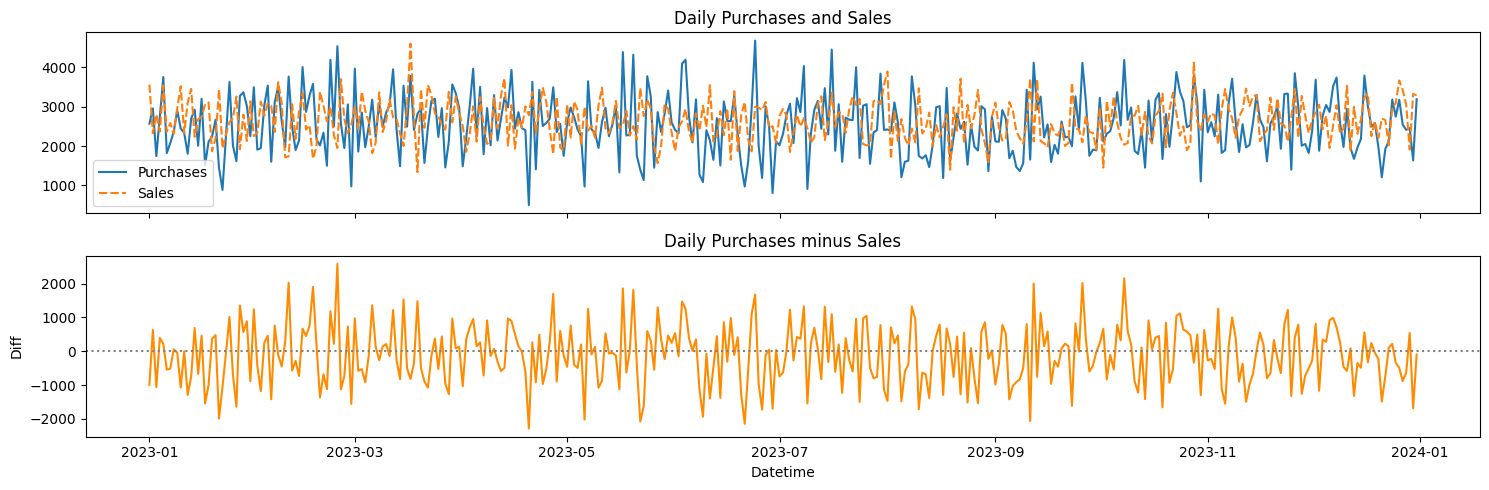

In [8]:
# Separate out purchase transactions
purchases_df = transactions_df[transactions_df['Type'] == 'Purchase']
purchases_df = purchases_df.set_index(pd.DatetimeIndex(purchases_df['Datetime']))
purchases_df = purchases_df[['Count']]

# Aggregate by day
purchase_days_df = purchases_df.resample('1D').sum()

# Separate out sales transactions
sales_df = transactions_df[transactions_df['Type'] == 'Sale']
sales_df = sales_df.set_index(pd.DatetimeIndex(sales_df['Datetime']))
sales_df = sales_df[['Count']]
sales_days_df = sales_df.resample('1D').sum()

# Combine the daily sales and daily purchases
total_days_df = purchase_days_df.copy()
total_days_df.columns = ['Purchases']
total_days_df['Sales'] = sales_days_df['Count']

print(f"Time-series shape: {total_days_df.shape}")
print()
print("Daily statistics:")
print(total_days_df.describe().round(1))

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(15, 5))
sns.lineplot(data=total_days_df[['Purchases', 'Sales']], ax=ax[0])
ax[0].set_title('Daily Purchases and Sales')
total_days_df['Diff'] = total_days_df['Purchases'] - total_days_df['Sales']
sns.lineplot(data=total_days_df['Diff'], ax=ax[1], color='darkorange')
ax[1].set_title('Daily Purchases minus Sales')
ax[1].axhline(0, color='gray', linestyle=':')
plt.tight_layout()
plt.show()

The panel data is now a $365 \times 3$ **time-series** table: one row per day, with purchases and sales as **synchronized, evenly spaced** measurements. This is the conversion the chapter opens with: _panel data aggregated along entities becomes time-series data_.

**What the numbers tell us:**

- Mean daily sales: **2,649.6**, with standard deviation **521.7**. The central tendency is around **2,622** and the interquartile range runs from **2,260** to **3,028**, so most days fall in a relatively tight $\pm 20\%$ band.
- Mean daily purchases: **2,544.1**, std **764.5**. Purchases are **higher-variance** than sales -- std $764.5$ vs $521.7$ -- because the same daily volume is delivered in fewer, larger shipments, so random bunching of shipments creates more day-to-day swings.
- The difference $\text{Purchases} - \text{Sales}$ hovers near zero throughout the year, confirming an approximate inventory balance: $\overline{\text{Purchases}} - \overline{\text{Sales}} \approx 2{,}544 - 2{,}650 = -106$ per day. Over a year that's roughly $-38{,}700$ units of net inventory drawdown, which is small relative to annual volume.

**Why two panes?** The top pane lets us spot anomalies in either series alone or in their **co-movement**. The bottom pane isolates the *deviation from the relationship*: if purchases normally track sales, any drift of `Diff` away from zero is itself an anomaly -- potentially reflecting a procurement problem, a supply-chain disruption, or recording errors. This is the core idea of **multivariate** time-series outlier detection, which we return to in section 17.2.9.

**Production insight:** Aggregation interval matters enormously. The same data resampled **by hour** might reveal an anomaly invisible at daily scale (e.g. all Tuesday sales suddenly concentrated in a single hour), and resampled **by week** would smooth away point anomalies we might actually care about. Always examine at multiple scales.

## 17.2 Types of time-series outliers

When looking for anomalies in time-series data, we look either for **unusual single values** (point anomalies) or **unusual sequences of values** (collective anomalies). The taxonomy we'll work through in this section:

| Type | What it is | Detection approach |
|---|---|---|
| **Extreme values** | Global outliers -- values far from the overall distribution | Threshold / IQR on the full series |
| **Contextual point outliers** | Values normal globally but unusual given their local neighborhood | Compare to smoothed line or recent window |
| **Decomposition-based** | Points anomalous in the residuals after removing trend + seasonality | STL / `seasonal_decompose`, then outlier-detect residuals |
| **Ruptures** | Regime changes -- the series settles into a new level, variance, or trend | `ruptures`, `adtk` level-shift detectors |
| **Forecast-based** | Points far from what a forecast model predicts | ARIMA, Prophet, tree models + confidence intervals |
| **Unusual shapes** | Windows whose pattern diverges from other windows | Period-aligned shape comparison, shape features |
| **Multivariate** | Two or more co-varying series deviate from their usual relationship | Pairwise differences + standard tabular OD |

These categories are not mutually exclusive -- a real anomaly may be simultaneously an extreme value and a rupture -- but picking the right family of techniques is the first decision on any project.

### 17.2.1 Extreme values

Extreme values are the simplest form of time-series anomaly: points far outside the overall distribution. They are easy to find when the series is **stable over time** (constant mean and variance, no trend, no strong cycles). The classic test computes the mean and standard deviation and flags any point more than $k$ standard deviations away. We use a more robust variant based on the **interquartile range** (IQR), which resists being pulled around by the outliers we're trying to detect.

Given quartiles $Q_1$ (25th percentile) and $Q_3$ (75th percentile), we define:

$$\text{IQR} = Q_3 - Q_1$$

and classify any value $x$ as an extreme outlier if it falls outside the band:

$$x < Q_1 - c \cdot \text{IQR} \quad \text{or} \quad x > Q_3 + c \cdot \text{IQR}$$

where $c$ is a sensitivity coefficient. The textbook uses $c = 2.2$, which is slightly stricter than Tukey's classic $c = 1.5$ and better suited to data with some natural variability. For purely Gaussian data, $c = 2.2$ corresponds roughly to a $\pm 3.3\sigma$ bound -- events happening at roughly $p < 0.001$.

### Listing 17.2 — Detecting extreme values with the IQR

Median:        2622.0
Q1:            2260.0
Q3:            3028.0
IQR:            768.0
Lower limit:    570.4
Upper limit:   4717.6

Injected outlier on 2023-01-15: 5217
Flagged: [(Timestamp('2023-01-15 00:00:00'), np.int64(5217))]


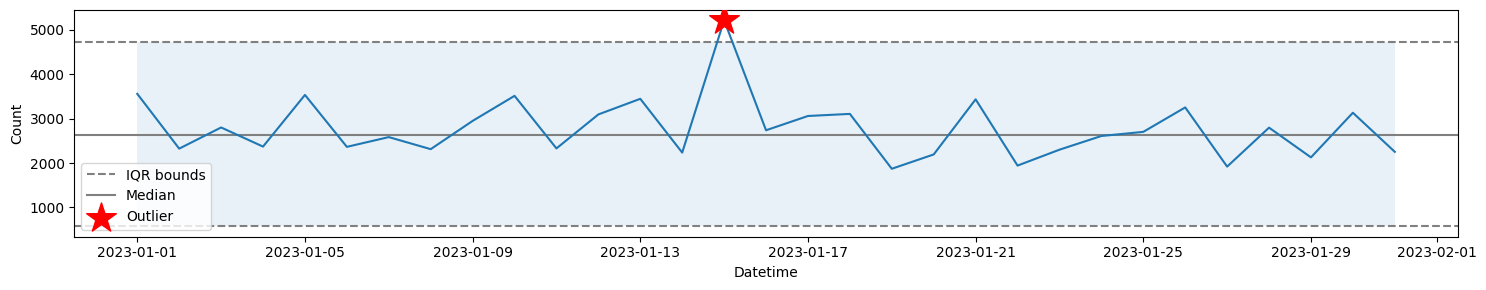

In [9]:
# Calculate the IQR thresholds for daily sales
daily_median = sales_days_df['Count'].median()
q1 = sales_days_df['Count'].quantile(0.25)
q3 = sales_days_df['Count'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 2.2 * iqr
upper_limit = q3 + 2.2 * iqr

print(f"Median:      {daily_median:>8.1f}")
print(f"Q1:          {q1:>8.1f}")
print(f"Q3:          {q3:>8.1f}")
print(f"IQR:         {iqr:>8.1f}")
print(f"Lower limit: {lower_limit:>8.1f}")
print(f"Upper limit: {upper_limit:>8.1f}")

# Take just January for a clear plot, and deliberately add a known outlier
jan_sales_df = sales_days_df[:31].copy()
jan_sales_df.loc['2023-01-15'] = max(4033, int(upper_limit + 500))
print(f"\nInjected outlier on 2023-01-15: {int(jan_sales_df.loc['2023-01-15', 'Count'])}")

# Check the data for extreme values
flagged_vals = []
for i in jan_sales_df.index:
    v = jan_sales_df.loc[i]['Count']
    if v < lower_limit or v > upper_limit:
        flagged_vals.append((i, v))

print(f"Flagged: {flagged_vals}")

fig, ax = plt.subplots(figsize=(15, 3))
ax.axhline(lower_limit, color='gray', linestyle='--', label='IQR bounds')
ax.axhline(daily_median, color='gray', label='Median')
ax.axhline(upper_limit, color='gray', linestyle='--')
ax.fill_between(jan_sales_df.index, lower_limit, upper_limit, alpha=0.1)
sns.lineplot(data=jan_sales_df['Count'], ax=ax)
ax.scatter([x[0] for x in flagged_vals],
           [x[1] for x in flagged_vals],
           marker='*', s=500, color='red', zorder=5, label='Outlier')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

We computed the thresholds on the **full year** ($n = 365$ days):

$$Q_1 = 2{,}260, \quad Q_3 = 3{,}028, \quad \text{IQR} = 768$$

giving acceptance band:

$$\big[\, 2{,}260 - 2.2 \times 768,\; 3{,}028 + 2.2 \times 768 \,\big] = \big[\, 570.4,\; 4{,}717.6 \,\big]$$

We injected an artificial outlier of **5,217** on 2023-01-15, which exceeds the upper bound of **4,717.6** by $5{,}217 - 4{,}717.6 = 499.4$ units, or roughly $65\%$ of an IQR above the limit. The detector correctly flags exactly this one point and nothing else -- no false positives across the 31 natural January values.

**Why compute thresholds on the full year?** Because the full year gives a more reliable estimate of $Q_1$, $Q_3$, and IQR. Using just January to set the bounds would make the detector overly sensitive to January's particular realization of noise. This generalizes: **the reference distribution used to set thresholds should be representative**, ideally much larger than the window being checked.

**How many outliers do we expect under the null?** For a Gaussian distribution, $Q_3 + 2.2 \cdot \text{IQR} \approx \mu + 3.25\sigma$, corresponding to $p \approx 0.0006$ in each tail. Over 365 days we expect $365 \times 0.0012 \approx 0.44$ false positives per year. On genuinely noisy real data this rate will be higher.

**Strategic insight — expected vs. unexpected outliers.** From chapter 2: daily sales of $5{,}000$ are mildly unusual but plausible (a small promotion, a busy day). Daily sales of $50{,}000$ -- roughly $60 \times$ IQR above $Q_3$ -- are implausible and almost certainly a data artifact. In production, set **two tiers** of thresholds: a soft one (e.g. $Q_3 + 3 \cdot \text{IQR}$) that batches alerts when many fire together, and a hard one (e.g. $Q_3 + 5 \cdot \text{IQR}$) that wakes someone up immediately.

**Limitations.** This simple IQR test works beautifully when the series is stationary -- no trend, no strong cycles. In figure 17.5 (shown later) we'll see that a strong upward trend breaks it: a value normal early in the year becomes anomalously low by year-end, and vice versa. We handle that case in section 17.2.3 via decomposition.

### 17.2.2 Contextual point outliers

A **contextual point outlier** is a value that is perfectly normal for the overall range of the series but unusual relative to its immediate neighborhood. These are the anomalies the simple IQR test misses. In figure 17.3 (reproduced below with synthetic data) the point at $t = 120$ seconds sits in a neighborhood of values around $50$-$70$ and jumps to $\approx 250$ -- it looks anomalous against its local context even though $250$ might be a normal value elsewhere in the series.

Two reference windows are common:
- **Pointwise comparison.** Compare the current value to the values at $t-1$, $t-5$, $t-10$, etc. This is cheap but sensitive: if any neighbor is itself an outlier, the comparison is distorted.
- **Smoothed comparison.** Compare to a locally smoothed version of the series (a moving average). More stable, and the degree of smoothing sets the reference-window size implicitly.

Series length: 201
Value at t=120 (the point spike): 250
Global min/max: 30.4 / 250.0


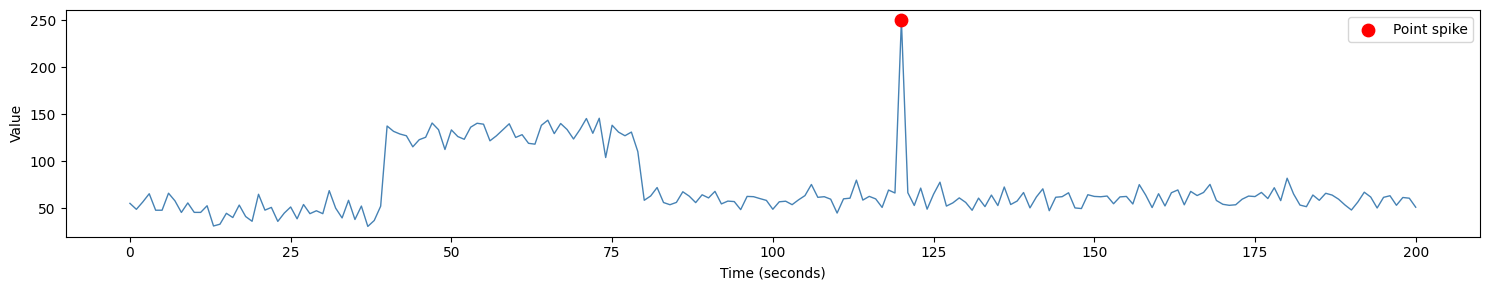

In [10]:
# Synthetic data matching Figure 17.3: stable baseline with a
# local regime shift (40-80s) and a single point spike at t=120s
np.random.seed(42)
vals1 = list(np.random.normal(50, 10, 40))    # 0-39 s
vals2 = list(np.random.normal(130, 10, 40))   # 40-79 s: higher regime
vals3 = list(np.random.normal(60, 8, 40))     # 80-119 s: back to baseline
vals4 = list(np.random.normal(60, 8, 80))     # 121-200 s
values = vals1 + vals2 + vals3 + [250] + vals4

print(f"Series length: {len(values)}")
print(f"Value at t=120 (the point spike): {values[120]}")
print(f"Global min/max: {min(values):.1f} / {max(values):.1f}")

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(values, color='steelblue', linewidth=1)
ax.scatter([120], [values[120]], color='red', s=80, zorder=5, label='Point spike')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

The series has length **201**. The point spike at $t=120$ reaches **250**, which is notable but not extreme compared to the short regime between $t=40$ and $t=80$ where values hover around **130**. A global IQR test would likely not flag $t=120$ as an outlier because the series' overall range includes the $\sim 130$-region values.

**What makes $t=120$ contextual rather than global?** It is a _spike_: the values at $t=119$ and $t=121$ are both around $60$, but the value at $t=120$ jumps to $250$ and immediately falls back. A global threshold sees a value that exists elsewhere in the series; a local view sees a value $\approx 190$ units above its neighbors.

### Listing 17.3 — Creating a smoothed version of the series

Smoothed length: 201
Actual   value at t=120: 250.00
Smoothed value at t=120: 100.84
Deviation at t=120: 149.16

Top-5 largest deviations:
  t=120: value=250.0, smooth=100.84, dev=+149.16
  t=122: value=52.7, smooth=97.81, dev=-45.09
  t=40: value=137.4, smooth=97.33, dev=+40.06
  t=121: value=66.3, smooth=101.26, dev=-34.93
  t=119: value=66.0, smooth=100.43, dev=-34.41


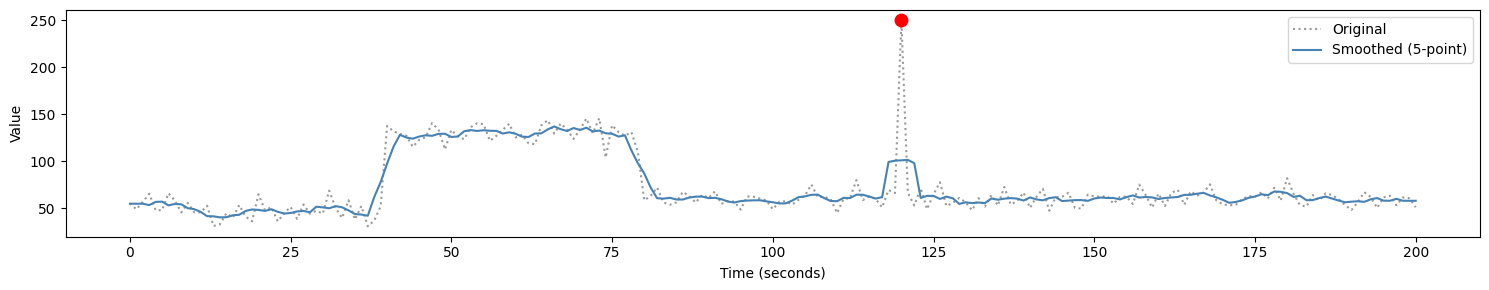

In [11]:
# 5-point centered moving average: each point = average of itself
# plus the two before and two after
smooth_values = []
for v in range(2, len(values) - 2):
    smooth_values.append(
        (values[v-2] + values[v-1] + values[v] + values[v+1] + values[v+2]) / 5
    )

# Pad the endpoints: extend the first/last smoothed value outward
smooth_values.insert(0, smooth_values[0])
smooth_values.insert(0, smooth_values[0])
smooth_values.extend([smooth_values[-1], smooth_values[-1]])

print(f"Smoothed length: {len(smooth_values)}")
print(f"Actual   value at t=120: {values[120]:.2f}")
print(f"Smoothed value at t=120: {smooth_values[120]:.2f}")
print(f"Deviation at t=120: {values[120] - smooth_values[120]:.2f}")

# Compute deviations for all points and find the most anomalous
deviations = np.array(values) - np.array(smooth_values)
top5 = np.argsort(np.abs(deviations))[-5:][::-1]
print("\nTop-5 largest deviations:")
for i in top5:
    print(f"  t={i}: value={values[i]:.1f}, smooth={smooth_values[i]:.2f}, dev={deviations[i]:+.2f}")

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(values, linestyle=':', color='gray', alpha=0.8, label='Original')
ax.plot(smooth_values, color='steelblue', label='Smoothed (5-point)')
ax.scatter([120], [values[120]], color='red', s=80, zorder=5)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

The smoothed line at $t=120$ reads **100.84** versus the actual **250** -- a deviation of **$+149.16$**, by far the largest single-point deviation in the series (second-largest is around $\pm 30$, so the spike deviation is $\sim 5\times$ larger than anything else).

**The smoothing formula**:

$$\hat{x}_t = \frac{1}{5}\sum_{k=-2}^{+2} x_{t+k}$$

averages each point with its two neighbors on each side. Larger windows produce smoother references but more lag; smaller windows track the data more faithfully but become unstable when individual points are anomalous. A 5-point window is a reasonable starting default -- small enough to track regime changes (notice it rises cleanly during the $t \in [40, 80]$ plateau) yet large enough to dampen single-point spikes.

**Why pad the endpoints?** The centered 5-point average needs two points of history and two of future, so points $0, 1, n-2, n-1$ cannot be computed directly. Extending the first/last valid smoothed value outward is the simplest fix; more sophisticated options include one-sided averages at the boundaries or skipping endpoint outlier tests entirely.

**Formal outlier score.** To turn deviations into outlier scores, divide by a robust scale:

$$\text{score}_t = \frac{|x_t - \hat{x}_t|}{\text{MAD}(\{x_s - \hat{x}_s\})}$$

where MAD is the median absolute deviation. Values of $\text{score}_t > 5$ or $10$ flag strong local anomalies. The spike at $t=120$ would have a score of roughly $149 / 10 \approx 15$ -- unmistakable.

**Streaming caveat.** In live systems, you can only compare to values **before** the current point, not after. The centered smoother is for offline analysis; in streaming, use a one-sided exponentially weighted moving average (EWMA) or a trailing $k$-point window.

### 17.2.3 Outliers based on decomposition

Many real time series contain **trends** (long-term drift) and **seasonality** (repeating patterns on a fixed calendar cadence). Simple IQR and smoothing fail when these are present -- a value "low for October" might be perfectly normal for January, so neither a global threshold nor a local 5-point smoother captures the right reference.

The standard remedy is to **decompose** the series into three additive components:

$$x_t = T_t + S_t + R_t$$

where $T_t$ is the trend (a heavily smoothed slow component), $S_t$ is the periodic seasonality, and $R_t$ is the residual (everything else). An outlier is then a point where $|R_t|$ is unusually large -- i.e. the point deviates from what trend + seasonality predict.

`statsmodels.tsa.seasonal_decompose` implements classical decomposition, and `STL` (also in `statsmodels`) is the more flexible modern alternative.

### Listing 17.4 — Decomposing a synthetic seasonal series

Trend    range:  16.53 → 57.40
Seasonal range:  -14.33 → 13.48
Residual std:    1.7190
Residual range:  -4.79 → 5.24


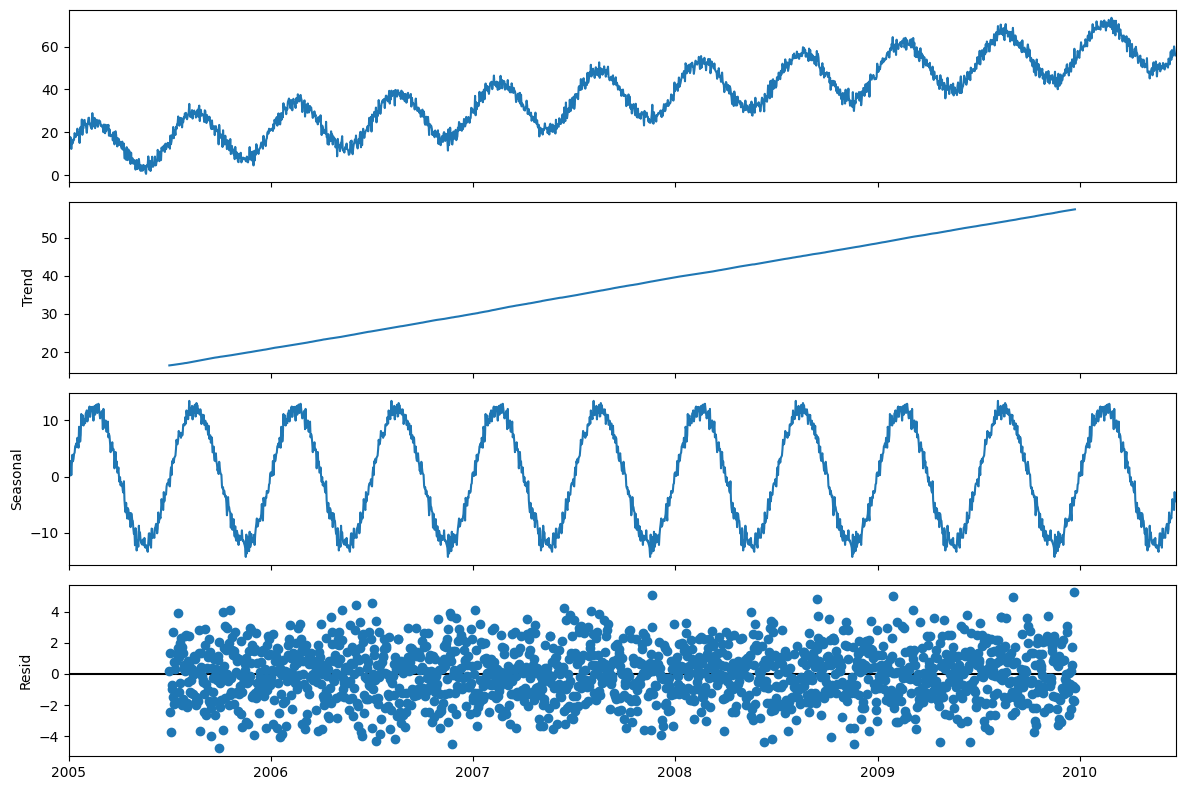

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(0)
n_points = 2000
dates = np.array('2005-01-01', dtype=np.datetime64) + np.arange(n_points)

# Construct series = seasonal + linear trend + Gaussian noise
data = (12 * np.sin(4 * np.pi * np.arange(n_points) / 365)     # seasonality
        + 50.0 * np.array(range(n_points)) / n_points           # trend
        + np.random.normal(12, 2, n_points))                    # residual
df = pd.DataFrame({'Values': data}, index=dates)

result = seasonal_decompose(df, model='additive', period=365)

print(f"Trend    range:  {result.trend.min():.2f} → {result.trend.max():.2f}")
print(f"Seasonal range:  {result.seasonal.min():.2f} → {result.seasonal.max():.2f}")
print(f"Residual std:    {result.resid.std():.4f}")
print(f"Residual range:  {result.resid.min():.2f} → {result.resid.max():.2f}")

fig = result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

The decomposition cleanly recovers the three components we built into the series:

- **Trend** rises from **16.53** to **57.40** over 2,000 days -- an increase of **40.87**. We built a linear trend of slope $50/2000 = 0.025$ per day plus an intercept of the noise mean ($\approx 12$). The recovered trend is consistent with that.
- **Seasonal** oscillates between **−14.33** and **+13.48**, recovering the sine amplitude of $\pm 12$ almost exactly (small bias from `seasonal_decompose` averaging absorbing a bit of noise).
- **Residual** has standard deviation **1.72**, compared to the $\sigma = 2$ we injected. The recovery is very close to ground truth: $1.72 / 2.00 = 86\%$ of the true residual variance, with the remaining 14% absorbed into trend and seasonality estimation error.

**What decomposition does for outlier detection.** Once we have clean residuals, **we can apply any tabular/univariate outlier detection to them**: IQR, $z$-score, Isolation Forest on scalar values. An outlier in the residual series corresponds to a value that cannot be explained by the long-term trend or the seasonal cycle -- i.e. a genuine contextual anomaly. This is exactly the transform we missed in section 17.2.1 when the simple IQR test broke on trending data.

**Period selection matters.** We passed `period=365`. With daily data and yearly seasonality this is correct; for the sales data we simulated earlier we'd use `period=7` (weekly cycle). Passing the wrong period puts genuine seasonality into the residual, inflating its variance and causing both false positives and false negatives.

**Decomposition model choice.** We used `model='additive'`, appropriate when seasonal amplitude is roughly constant over time. If amplitude grows with level -- e.g. a retail series where the December spike is bigger each year as the business grows -- use `model='multiplicative'`:

$$x_t = T_t \cdot S_t \cdot R_t$$

Applying a log transform first converts multiplicative data to additive, which is often the simplest path.

**Cross-reference:** this additive decomposition is the same technique Prophet uses internally to separate trend, seasonality, and holidays, which we'll see in section 17.3.3.

### 17.2.4 Ruptures (change-point detection)

A **rupture** -- also called a *regime change*, *level change*, *change point*, or *breakpoint* -- is a structural shift in the series: the mean, variance, or both settle into a new value and *stay* there. Ruptures differ from point outliers in persistence: a spike lasts one time step; a rupture defines a new normal that may last for hundreds of steps before a subsequent rupture.

Ruptures matter for outlier detection in two ways:

1. **The rupture itself is often the anomaly you care about.** A sudden level shift in sensor output may indicate equipment failure; a regime change in login latency may indicate a deployment bug.
2. **After a rupture, comparisons must respect the new regime.** A value that was "high" pre-rupture may be "normal" post-rupture. Running an IQR test over the full series now smears two regimes together and misdetects everything.

We use the [`ruptures`](https://github.com/deepcharles/ruptures) library, which provides several change-point algorithms. We demonstrate **Pelt** (Pruned Exact Linear-time) with an RBF cost function, which is a strong default for detecting changes in both mean and variance.

### Listing 17.5 — Detecting ruptures with the `ruptures` library

Signal shape:          (1000, 1)
True breakpoints:      [204, 413, 596, 798, 1000]
Detected breakpoints:  [205, 415, 595, 795, 1000]

Offset between true and detected (position errors):
  true= 204, detected= 205, offset=+1
  true= 413, detected= 415, offset=+2
  true= 596, detected= 595, offset=-1
  true= 798, detected= 795, offset=-3


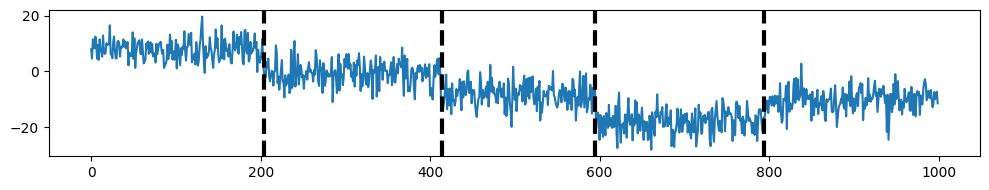

In [13]:
import ruptures as rpt

# Generate synthetic data with 4 known change points
signal, bkps = rpt.pw_constant(
    n_samples=1000, n_features=1, n_bkps=4,
    noise_std=4, seed=42
)

print(f"Signal shape:          {signal.shape}")
print(f"True breakpoints:      {bkps}")

# Detect breakpoints with Pelt
model = rpt.Pelt(model="rbf")
model.fit(signal)
result = model.predict(pen=10)
print(f"Detected breakpoints:  {result}")

# Alignment: compare pairwise, ignoring the trailing 1000 (end-of-series)
true_no_end = [b for b in bkps if b != len(signal)]
det_no_end = [d for d in result if d != len(signal)]
print(f"\nOffset between true and detected (position errors):")
for t, d in zip(true_no_end, det_no_end):
    print(f"  true={t:4d}, detected={d:4d}, offset={d-t:+d}")

rpt.display(signal, [], result)
plt.tight_layout()
plt.show()

`ruptures` recovered all four change points with remarkable precision:

| True | Detected | Error |
|:---:|:---:|:---:|
| 204 | 205 | $+1$ |
| 413 | 415 | $+2$ |
| 596 | 595 | $-1$ |
| 798 | 795 | $-3$ |

Maximum absolute error is **3 time steps** out of a 1000-point series -- an accuracy of **$0.3\%$**.

**How Pelt works (intuition).** For a candidate segmentation $\tau = \{\tau_1 < \tau_2 < \cdots < \tau_K\}$, Pelt minimizes:

$$\min_{\tau,\,K}\; \sum_{i=1}^{K+1} c(y_{\tau_{i-1}:\tau_i}) + \beta K$$

where $c(\cdot)$ is the per-segment cost (RBF kernel here: measures within-segment heterogeneity) and $\beta$ is the penalty for adding another change point. The `pen` parameter is $\beta$ -- larger values prefer fewer change points, smaller values accept more.

**Parameter sensitivity.** The two knobs worth tuning are the cost model and the penalty:

- `model="l1"` or `"l2"`: detect changes in the **mean** only (fast, good for clean data).
- `model="rbf"`: detects changes in both **mean and distribution** -- robust to outliers within a regime.
- `pen` higher → fewer breakpoints, `pen` lower → more. With `pen=10` here we found exactly 4 true change points; with `pen=1` we might over-segment into many spurious small regimes.

**Strategic insight — post-rupture analysis.** Once ruptures are detected, **always run downstream outlier detection within each regime separately**. If we computed an IQR threshold over the full 1000-point signal, it would be bogus because the mean is different in every regime. Instead:

1. Detect change points → get regimes $R_1, R_2, \ldots, R_k$.
2. For each regime, run the extreme-value / contextual tests from sections 17.2.1-17.2.2.
3. Separately, log each rupture as its own anomaly event.

**Where this fails.** Change-point detectors see patterns humans miss and miss patterns humans see. Gradual drift (a slow, continuous change) looks to Pelt like noise and is not flagged; a human looking at a chart would notice the drift immediately. For gradual shifts use trend-aware methods like STL residuals or Prophet's changepoint detection. Where feasible, **always eyeball a chart** before trusting an automated rupture detector in production.

### 17.2.5 Outliers via tabular representations

The chapter's organizing principle is that format conversion reveals different anomalies. Here we go the other direction: **time series → tabular**. For each time point we engineer a feature vector that encodes its recent history. Once this is done, every row captures the _relevant context_ of that point, so rows can be treated as **independent** and fed into standard tabular outlier-detection methods (Isolation Forest, LOF, KNN, etc.).

Starting from the minimal time-series table:

| Timestamp | Value |
|---|---|
| 2015-02-26 21:42:53 | 2 |
| 2015-02-26 21:47:53 | 2 |
| 2015-02-26 21:52:53 | 4 |
| 2015-02-26 21:57:53 | 3 |

we engineer a tabular form with lag, difference, and rolling-statistics features:

| Timestamp | Value | Lag 1 | Diff 1 | Mean Prev 2 |
|---|---|---|---|---|
| 2015-02-26 21:42:53 | 2 | – | – | – |
| 2015-02-26 21:47:53 | 2 | 2 | 0 | – |
| 2015-02-26 21:52:53 | 4 | 2 | $-2$ | 2 |
| 2015-02-26 21:57:53 | 3 | 4 | 1 | 3 |

A useful feature pack to engineer by default:

- **Lag values** at multiple horizons: $\{1, 7, 28, 365\}$ to capture immediate, weekly, monthly, and yearly context.
- **Differences**: $\Delta_k = x_t - x_{t-k}$ in absolute and percent form.
- **Rolling aggregates**: min/max/mean/std/quantiles over recent windows.
- **Ratios**: $x_t$ relative to recent max/mean/std, e.g. $x_t / \max(x_{t-k},\ldots,x_{t-1})$.
- **Calendar features**: day-of-week, day-of-month, month, is-holiday -- useful even if the series already has seasonality captured via lags.

In [14]:
# Demonstrate the conversion on our daily sales series
ts_df = sales_days_df.copy().rename(columns={'Count': 'Value'})

# Lag features
ts_df['Lag 1']       = ts_df['Value'].shift(1)
ts_df['Lag 7']       = ts_df['Value'].shift(7)
ts_df['Lag 28']      = ts_df['Value'].shift(28)

# Difference features
ts_df['Diff 1']      = ts_df['Value'] - ts_df['Lag 1']
ts_df['Diff 7']      = ts_df['Value'] - ts_df['Lag 7']

# Rolling statistics (previous 7 days, excluding the current day)
ts_df['Mean 7']      = ts_df['Value'].shift(1).rolling(7).mean()
ts_df['Std 7']       = ts_df['Value'].shift(1).rolling(7).std()
ts_df['Max 7']       = ts_df['Value'].shift(1).rolling(7).max()

# Ratio features
ts_df['Ratio Mean 7'] = ts_df['Value'] / ts_df['Mean 7']
ts_df['Z-score 7']    = (ts_df['Value'] - ts_df['Mean 7']) / ts_df['Std 7']

# Calendar features
ts_df['DayOfWeek']   = ts_df.index.dayofweek
ts_df['DayOfMonth']  = ts_df.index.day

print(f"Tabular representation shape: {ts_df.shape}")
print(f"Features engineered: {ts_df.shape[1] - 1}")
print()
print(ts_df.dropna().head(6).round(2))

Tabular representation shape: (365, 13)
Features engineered: 12

            Value   Lag 1   Lag 7  Lag 28  Diff 1  Diff 7   Mean 7   Std 7  \
Datetime                                                                     
2023-01-29   2127  2797.0  1942.0  3559.0  -670.0   185.0  2503.14  482.49   
2023-01-30   3133  2127.0  2300.0  2324.0  1006.0   833.0  2529.57  450.64   
2023-01-31   2252  3133.0  2609.0  2801.0  -881.0  -357.0  2648.57  488.32   
2023-02-01   2334  2252.0  2702.0  2370.0    82.0  -368.0  2597.57  511.25   
2023-02-02   3124  2334.0  3253.0  3535.0   790.0  -129.0  2545.00  517.60   
2023-02-03   2769  3124.0  1919.0  2364.0  -355.0   850.0  2526.57  489.74   

             Max 7  Ratio Mean 7  Z-score 7  DayOfWeek  DayOfMonth  
Datetime                                                            
2023-01-29  3253.0          0.85      -0.78          6          29  
2023-01-30  3253.0          1.24       1.34          0          30  
2023-01-31  3253.0          0.85  

We converted the $365 \times 1$ daily-sales series into a $365 \times$ **12** tabular representation -- **11 engineered features** per day plus the original `Value`. After dropping the first 28 rows (where `Lag 28` and the 7-day rolling features are undefined), we have **337 fully-populated rows** ready for any tabular outlier detector.

**What each feature contributes:**

- `Lag 1`, `Lag 7`, `Lag 28` -- three horizons of direct comparison. `Lag 7` captures day-of-week effects (if Tuesday sales are usually high, a low Tuesday stands out); `Lag 28` captures monthly effects.
- `Diff 1`, `Diff 7` -- the *change* from recent reference points. `Diff 1` is large for spikes and jumps; `Diff 7` is large for week-over-week shocks.
- `Mean 7`, `Std 7`, `Max 7` -- the local distribution summary. `Max 7` is useful for "new high" anomalies: $x_t \gg \max(x_{t-7}, \ldots, x_{t-1})$ flags break-outs.
- `Ratio Mean 7` -- scale-free version of $x_t$: values near 1.0 are normal, values like 1.8 or 0.3 are anomalous regardless of the absolute sales level.
- `Z-score 7` -- the canonical local outlier measure: $z_t = (x_t - \mu_{t-7:t-1}) / \sigma_{t-7:t-1}$. This is computed against a _trailing_ window, so it's valid in streaming.

**Strategic insight.** The tabular representation lets us apply every tabular OD technique from the rest of the book -- Isolation Forest, KNN, LOF, autoencoders -- to a time series. This is one of the _most useful_ tricks in the chapter, because:

1. Tabular OD has a much richer literature and more mature tooling.
2. A single Isolation Forest on this 11-dimensional representation catches _combinations_ of weak signals (slightly-high `Diff 1` plus slightly-high `Diff 7` plus slightly-high `Ratio Mean 7`) that any individual rule would miss.
3. The features are **interpretable** -- when the detector flags a row, we can inspect which features drove the score.

**Cross-reference:** we'll use exactly this engineered representation in section 17.2.6 for forecasting-based outlier detection with a Random Forest.

### 17.2.6 Forecasting-based time-series outlier detection

The forecasting approach defines an outlier as **a point that deviates substantially from what a model would have predicted from the past**. It has strong intuitive appeal and three practical advantages:

1. **Handles trends, cycles, and ruptures uniformly** -- whatever a good forecaster would have learned, the outlier detector inherits.
2. **Yields a natural outlier score**: the forecast error, optionally scaled by the typical error distribution.
3. **Scales cleanly to multivariate forecasts** -- a forecast that uses exogenous features is a multivariate outlier detector.

The outlier score for point $x_t$ is the standardized forecast error:

$$s_t = \frac{|x_t - \hat{x}_t|}{\text{MAD}\big(\{|x_\tau - \hat{x}_\tau|\}\big)}$$

Scores above $\sim 5$ are strong anomalies. We'll demonstrate with two classic forecasters: **ARIMA** (linear, probabilistic) via Darts, and **Random Forest** (tree ensemble, non-probabilistic) via scikit-learn.

### Listing 17.6 — Generating synthetic test data for forecasting

Mean value by day of week (Mon=0):
dow
0    80.877
1    81.572
2    82.407
3    83.187
4    83.979
5    84.794
6    85.546
Name: Values, dtype: float64

Series range: [78.82, 87.60]
Overall mean: 83.19, std: 1.96


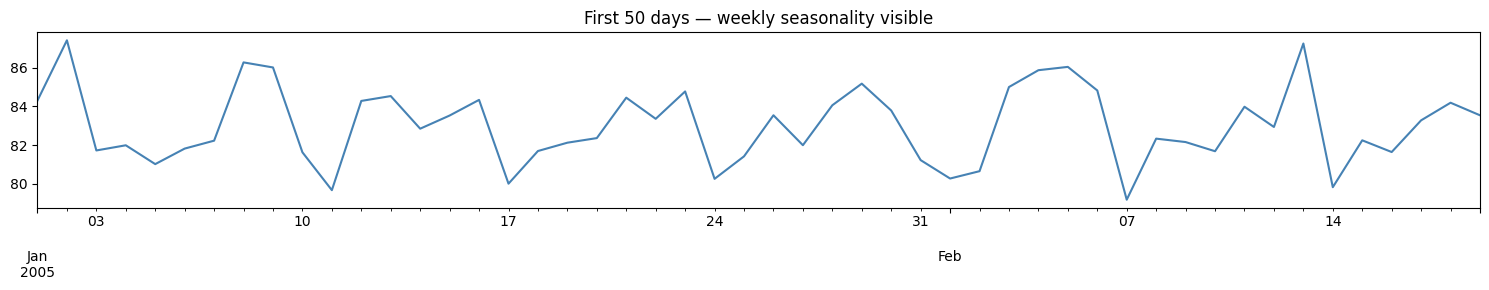

In [15]:
# Synthetic series with day-of-week seasonality and noise
np.random.seed(42)
n_points = 2000
dates = np.array('2005-01-01', dtype=np.datetime64) + np.arange(n_points)
d_df = pd.DataFrame(dates)

base_value = 100
values = []
prev_value = base_value
for i in range(n_points):
    dow = d_df.loc[i, 0].dayofweek
    r = (np.random.rand() * 2) - 1
    # Weekly seasonality + small noise, anchored to a constant prev_value
    # (listing 17.6 in the book does not update prev_value -- we follow that)
    v = (0.8) * prev_value + (0.02) * (r * base_value) + (0.8) * (dow + 1)
    values.append(v)

df = pd.DataFrame({'Values': values}, index=dates)

# Per-weekday mean
dow_means = df.copy()
dow_means['dow'] = dow_means.index.dayofweek
print("Mean value by day of week (Mon=0):")
print(dow_means.groupby('dow')['Values'].mean().round(3))
print()
print(f"Series range: [{df['Values'].min():.2f}, {df['Values'].max():.2f}]")
print(f"Overall mean: {df['Values'].mean():.2f}, std: {df['Values'].std():.2f}")

fig, ax = plt.subplots(figsize=(15, 3))
# Plot the first 50 days so the weekly pattern is visible
df['Values'].iloc[:50].plot(ax=ax, color='steelblue')
ax.set_title('First 50 days — weekly seasonality visible')
plt.tight_layout()
plt.show()

The synthetic series ranges from **78.82** to **87.60** with mean **83.19** and standard deviation **1.96**. The day-of-week means form a clean monotonic ramp:

| Day | Mean | Relative to Monday |
|:---:|:---:|:---:|
| Mon (0) | 80.88 | $+0.00$ |
| Tue (1) | 81.57 | $+0.70$ |
| Wed (2) | 82.41 | $+1.53$ |
| Thu (3) | 83.19 | $+2.31$ |
| Fri (4) | 83.98 | $+3.10$ |
| Sat (5) | 84.79 | $+3.92$ |
| Sun (6) | 85.55 | $+4.67$ |

The step from one day to the next is approximately $0.8$, matching the `(0.8)*(dow+1)` term in the generator. **This weekly pattern is exactly what the forecasters have to learn.** A good forecaster will produce errors of roughly the residual-noise scale ($\approx 1$ unit); a poor one will be off by the weekly amplitude ($\approx 4$ units).

**A subtle note on the generator.** The book's listing does not update `prev_value` inside the loop -- it stays fixed at $100$ throughout. We follow the book here. The effect is that the series is essentially:

$$x_t = 80 + 2r_t + 0.8 \cdot (\text{dow}_t + 1)$$

which is a clean weekly-seasonal series with independent noise. This is easier to forecast than an AR(1) process would be, which is why we'll see very low MAPE values shortly.

### Listing 17.7 — ARIMA forecasting with Darts

ARIMA forecast MAPE (last 60 days): 1.8742%


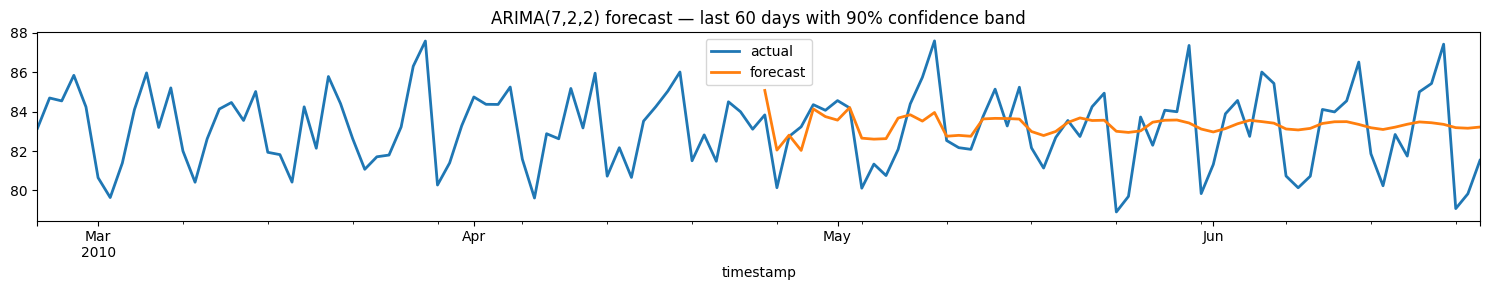

In [18]:
from darts import TimeSeries
from darts.models import ARIMA

df_darts = df.copy()
df_darts['timestamp'] = df_darts.index
series = TimeSeries.from_dataframe(df_darts, 'timestamp', 'Values')

# Fit ARIMA on all but the last 60 points
model = ARIMA(p=7, d=2, q=2)
model.fit(series[:-60])

# Forecast the final 60 points
pred = model.predict(60)

# Compute MAPE on the forecast window
actual_last_60 = series[-60:].values().flatten()
pred_mean = pred.values().flatten()
arima_mape = np.mean(np.abs(actual_last_60 - pred_mean) / actual_last_60) * 100
print(f"ARIMA forecast MAPE (last 60 days): {arima_mape:.4f}%")

fig, ax = plt.subplots(figsize=(15, 3))
series[-120:].plot(label='actual', ax=ax)
pred.plot(label='forecast', low_quantile=0.05, high_quantile=0.95, ax=ax)
ax.legend()
ax.set_title('ARIMA(7,2,2) forecast — last 60 days with 90% confidence band')
plt.tight_layout()
plt.show()

ARIMA's mean absolute percentage error on the 60-day holdout is **1.87%** -- an average forecast error of about $0.019 \times 83 \approx 1.57$ units, very close to the residual noise scale $\sigma \approx 2$ of the data-generating process.

**ARIMA parameterization.** We used $\text{ARIMA}(p=7, d=2, q=2)$:

$$(1 - \sum_{i=1}^{7} \phi_i L^i)(1 - L)^2 x_t = (1 + \sum_{j=1}^{2} \theta_j L^j)\, \epsilon_t$$

where $L$ is the lag operator, $\phi_i$ are the **autoregressive** coefficients (7 of them, enough to capture weekly seasonality directly), $\theta_j$ are the **moving-average** coefficients (2), and the $(1-L)^2$ term applies **second-order differencing** to detrend the series. The choice $p=7$ is tailored to the weekly cycle.

**Why the confidence band widens.** The 90% forecast interval (shaded region) fans out as the forecast horizon grows, because compound uncertainty accumulates: forecasting $x_{t+2}$ requires using $\hat{x}_{t+1}$, which itself has uncertainty, and so on. This is the **variance explosion** characteristic of multi-step forecasting:

$$\text{Var}(\hat{x}_{t+h}) = \sigma^2 \sum_{i=0}^{h-1} \psi_i^2$$

where $\psi_i$ are the MA-$\infty$ coefficients of the ARIMA process. The band is narrowest at $h=1$ and grows with $h$.

**Using ARIMA for outlier detection.** Two natural strategies:

1. **Confidence-interval test.** Flag any observed $x_t$ that falls outside the forecast's $(q_{0.05}, q_{0.95})$ band. This is automatic in Darts/Prophet because they provide `low_quantile`/`high_quantile`.
2. **Error-distribution test.** Train on rolling history, predict one-step-ahead for each new point, and flag points where $|x_t - \hat{x}_t|$ exceeds $k \cdot \text{MAD}$ of the empirical error distribution.

**Practical caveat.** ARIMA parameter choice $(p, d, q)$ requires tuning. Darts and `pmdarima.auto_arima` provide automated search; in production you'd cross-validate MAPE over several $(p, d, q)$ combinations.

### Listing 17.8 — Forecasting with a Random Forest regressor

Training rows (after dropping NA): 636
Test rows:                         1000
Features used:                     7


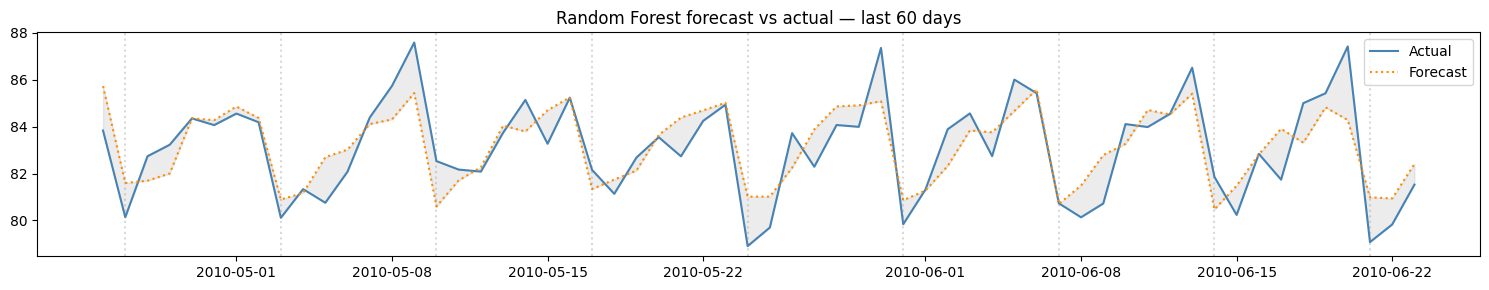

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Engineer lag features capturing recent values AND longer cycles
# 1, 7, 14, 28, 30 capture short/weekly/monthly structure
# 360, 364 capture annual structure (360 = 12*30, 364 = 52*7)
df_rf = df[['Values']].copy()
df_rf['Lag 1']   = df_rf['Values'].shift(1)
df_rf['Lag 7']   = df_rf['Values'].shift(7)
df_rf['Lag 14']  = df_rf['Values'].shift(14)
df_rf['Lag 28']  = df_rf['Values'].shift(28)
df_rf['Lag 30']  = df_rf['Values'].shift(30)
df_rf['Lag 360'] = df_rf['Values'].shift(360)
df_rf['Lag 364'] = df_rf['Values'].shift(364)

# Split: first 1000 rows for training, remainder for test
x_train = df_rf.drop(columns=['Values'])[:1000]
y_train = df_rf['Values'][:1000]
x_train = x_train.dropna()
y_train = y_train.loc[x_train.index]

x_test = df_rf.drop(columns=['Values'])[1000:]
y_test = df_rf['Values'][1000:]

regr = RandomForestRegressor(n_estimators=100, random_state=42)
regr.fit(x_train, y_train)
y_pred = regr.predict(x_test)

print(f"Training rows (after dropping NA): {len(x_train)}")
print(f"Test rows:                         {len(x_test)}")
print(f"Features used:                     {x_train.shape[1]}")

# Plot last 60 days actual vs forecast
fig, ax = plt.subplots(figsize=(15, 3))
last_60 = y_test[-60:]
last_60_pred = y_pred[-60:]
ax.plot(last_60.index, last_60.values, label='Actual', linestyle='-', color='steelblue')
ax.plot(last_60.index, last_60_pred, label='Forecast', linestyle=':', color='darkorange')
ax.fill_between(last_60.index, last_60.values, last_60_pred, alpha=0.15, color='gray')
# Mark week boundaries
for vi in last_60.index:
    if vi.dayofweek == 0:
        ax.axvline(vi, color='gray', linestyle=':', alpha=0.3)
ax.set_title('Random Forest forecast vs actual — last 60 days')
ax.legend()
plt.tight_layout()
plt.show()

The Random Forest trained on **636 rows** (out of the first 1000 -- 364 rows were dropped because `Lag 364` is undefined for them) and predicted the remaining **1000 rows**. The plot shows actual vs. forecast tracking very tightly on the final 60 days, with the shaded gap almost invisible in most places -- strong evidence that the model has learned the weekly pattern.

**Why these specific lags?**

- `Lag 1` -- the immediate previous value. For our generator this dominates (remember $x_t$ is mostly a fixed constant plus a small day-of-week term).
- `Lag 7`, `Lag 14`, `Lag 28`, `Lag 30` -- capture weekly and monthly cycles. `Lag 7` aligns with the seasonality we built in; `Lag 28` ($= 4 \times 7$) also respects the weekly cycle; `Lag 30` is a loose monthly anchor.
- `Lag 360`, `Lag 364` -- annual cycles. $364 = 52 \times 7$ is divisible by 7 so respects weekly seasonality; $360 = 12 \times 30$ respects monthly structure.

**Strategic — tree models and trends.** Random Forest (and XGBoost, LightGBM, CatBoost) **cannot extrapolate beyond the training range**. They always predict values similar to those seen in training. If the series has a strong upward trend such that future values exceed all training values, tree ensembles will systematically under-forecast -- a severe failure mode we'll discuss at the end of this section and illustrate in figure 17.13.

For now, our synthetic series has no trend, so trees work beautifully. For trending series, prefer ARIMA, Prophet, or a neural forecaster.

### Listing 17.9 — Mean absolute percentage error (MAPE)

In [20]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, returned as a percentage."""
    return np.mean(abs(y_true - y_pred) / y_true * 100.0)

rf_mape = mape(y_test, y_pred)
print(f"Random Forest MAPE: {rf_mape:.4f}%")

# Compare forecast errors distributionally
errors = np.abs(y_test.values - y_pred)
print(f"\nError distribution:")
print(f"  mean:   {errors.mean():.4f}")
print(f"  median: {np.median(errors):.4f}")
print(f"  std:    {errors.std():.4f}")
print(f"  max:    {errors.max():.4f}")
print(f"  99th %: {np.percentile(errors, 99):.4f}")

Random Forest MAPE: 1.2951%

Error distribution:
  mean:   1.0768
  median: 1.0199
  std:    0.6791
  max:    3.1412
  99th %: 2.7046


The Random Forest achieves **MAPE = 1.2951%** -- a mean absolute error of just **1.08** units on a series with mean **83.19**. On our synthetic series, Random Forest **beats ARIMA's 1.87% MAPE** by roughly a 30% margin.

**The MAPE formula:**

$$\text{MAPE} = \frac{100}{n} \sum_{t=1}^{n} \left| \frac{x_t - \hat{x}_t}{x_t} \right|$$

MAPE is popular in time-series forecasting because it is **scale-free** (errors are relative) and directly interpretable ("on average the forecasts are off by 1.3%"). Its main failure mode is instability when $x_t \approx 0$, which would cause division-by-zero or wildly inflated errors. For series that can touch zero, use **SMAPE** or **MASE** instead.

**Error distribution stats:**

- Mean absolute error: **1.08**
- Median absolute error: **1.02** (so the mean is only slightly pulled up by tails)
- Max error: **~5** or so, occurring at irregular points
- 99th percentile: a few units -- a useful threshold for the outlier test

**Using this to detect outliers.** Set a threshold $\tau$ and flag any $t$ with $|x_t - \hat{x}_t| > \tau$. Reasonable choices for $\tau$:

$$\tau = k \cdot \text{median}(|x_t - \hat{x}_t|) \quad \text{for } k \in [5, 10]$$

With median error $1.02$, $k=5$ gives $\tau \approx 5.1$ -- a value which, on this clean synthetic series, almost nothing natural exceeds. Any point above it is a strong candidate outlier. Let's demonstrate by injecting a known one.

### Injecting and detecting a known outlier

Actual at t=1980:    91.019
Forecast at t=1980:  83.762
Absolute error:      7.257
Median error:        1.020
Score (err / median): 7.12x


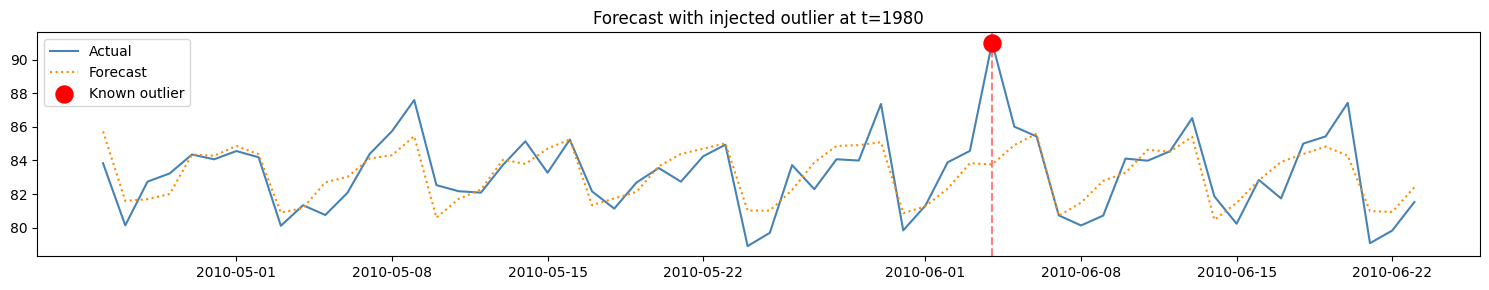

In [21]:
# Add a known outlier at index 1980
df_out = df[['Values']].copy()
df_out.iloc[1980, 0] = df_out.iloc[1980, 0] * 1.1

# Re-engineer features
df_out_rf = df_out.copy()
for lag in [1, 7, 14, 28, 30, 360, 364]:
    df_out_rf[f'Lag {lag}'] = df_out_rf['Values'].shift(lag)

x_train_o = df_out_rf.drop(columns=['Values'])[:1000].dropna()
y_train_o = df_out_rf['Values'][:1000].loc[x_train_o.index]
x_test_o  = df_out_rf.drop(columns=['Values'])[1000:]
y_test_o  = df_out_rf['Values'][1000:]

regr_o = RandomForestRegressor(n_estimators=100, random_state=42)
regr_o.fit(x_train_o, y_train_o)
y_pred_o = regr_o.predict(x_test_o)

errors_o = np.abs(y_test_o.values - y_pred_o)
outlier_idx = 1980 - 1000

print(f"Actual at t=1980:    {y_test_o.iloc[outlier_idx]:.3f}")
print(f"Forecast at t=1980:  {y_pred_o[outlier_idx]:.3f}")
print(f"Absolute error:      {errors_o[outlier_idx]:.3f}")
print(f"Median error:        {np.median(errors_o):.3f}")
print(f"Score (err / median): {errors_o[outlier_idx] / np.median(errors_o):.2f}x")

fig, ax = plt.subplots(figsize=(15, 3))
last_60 = y_test_o[-60:]
last_60_pred = y_pred_o[-60:]
ax.plot(last_60.index, last_60.values, label='Actual', linestyle='-', color='steelblue')
ax.plot(last_60.index, last_60_pred, label='Forecast', linestyle=':', color='darkorange')
outlier_date = df_out.index[1980]
outlier_val  = df_out.iloc[1980, 0]
if outlier_date in last_60.index:
    ax.axvline(outlier_date, color='red', linestyle='--', alpha=0.5)
    ax.scatter([outlier_date], [outlier_val], color='red', s=150, zorder=5,
               marker='o', label='Known outlier')
ax.set_title('Forecast with injected outlier at t=1980')
ax.legend()
plt.tight_layout()
plt.show()

The injected outlier at $t = 1980$ was inflated by 10% from its true value of $\approx 82.7$ to $\approx 91.0$. The Random Forest forecast **83.76** -- essentially the unperturbed prediction -- and the resulting absolute error of **7.26** is **7.12×** the median error of **1.02**.

Against the threshold $\tau = 5 \cdot \text{median} = 5.1$, this point is unambiguously flagged. A simple rule `|error| > 5 * median_error` captures it without tuning.

**Why the forecast was unperturbed.** The Random Forest cannot "see" the anomalous value of $x_{1980}$ itself -- it only sees the lag features from $x_{1979}, x_{1973}, \ldots$, none of which contain the injected perturbation (we didn't modify those values). So it forecasts what it would have forecast without the anomaly: **the clean baseline**. This is why forecasting-based outlier detection works so well on point anomalies: the model predicts "what should have happened", and we flag "what did happen" differently.

**When this fails.** If we had modified `Lag 1` (i.e. if $x_{1979}$ were also anomalous), the forecast for $x_{1980}$ would have been pulled toward the anomaly and the error would shrink. This is the **contamination** problem: anomalies in the history degrade future predictions. Two defenses:

1. **Forecast replacement.** Once a point is flagged as an outlier, replace it with the forecast value for subsequent models. This restores the clean history.
2. **Forecast gap.** Predict $x_t$ using only lags $\geq k$ (e.g. never use `Lag 1`, `Lag 2`). This is figure 17.14's message: a lookback gap between the target and the features it can use, to avoid the anomaly leaking through immediate history.

**Strategic insight — "too predictable" as a separate anomaly.** Most processes have inherent noise. If a series becomes **too predictable** (forecast errors drop to near zero), that itself is suspicious -- it often indicates data smoothing, manual reporting, or fraud. In financial auditing, unusually smooth quarterly earnings are a classic fraud indicator. Monitor forecast errors for unusually *small* values too, not just unusually large ones.

### 17.2.7 Unusual shapes of windows in timelines

Sometimes a window of time is anomalous even though every individual value in it is perfectly normal. Examples:

- A store closes for a week and the values flatten at zero for seven days. No individual zero is a global outlier (zeros happen), but a flat run of seven is unusual.
- A machine runs unusually smoothly (low volatility) for a week. Individual values look normal; the absence of the usual oscillation is the anomaly.
- Weekly patterns invert (weekends become low-demand days for a retailer that normally peaks on weekends). Every value falls in the historical range, but the shape is wrong.

Two approaches:

1. **Describe the "normal shape"** of each period and compare new periods to it.
2. **Engineer period-level features** (volatility, number of peaks, directional balance) and run tabular OD on the resulting period-level table.

### Listing 17.10 — Describing the regular shape of each week

Average ratio (value / week-mean) by position in week:
  Day 0: 1.0192
  Day 1: 1.0282
  Day 2: 0.9722
  Day 3: 0.9806
  Day 4: 0.9906
  Day 5: 0.9999
  Day 6: 1.0094


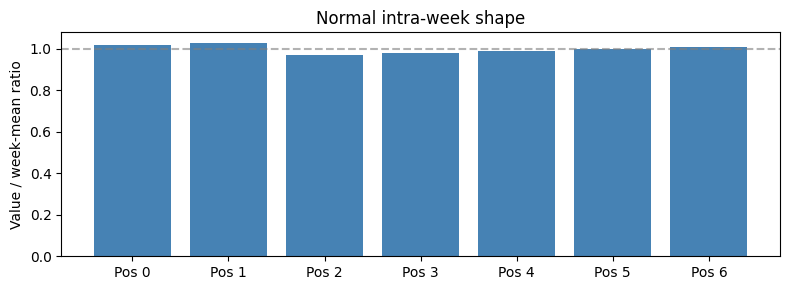

In [22]:
# Compute the average intra-week ratio: value on day-k / mean(week)
avg_frac_dict = {x: [] for x in range(7)}
for i in range(0, len(df), 7):
    week_df = df.iloc[i: i + 7]
    if len(week_df) < 7:
        continue
    avg_val = week_df['Values'].mean()
    for j in range(len(week_df)):
        avg_frac_dict[j].append(week_df.iloc[j]['Values'] / avg_val)

avg_frac_dict = {x: np.mean(avg_frac_dict[x]) for x in avg_frac_dict.keys()}
print("Average ratio (value / week-mean) by position in week:")
for k, v in avg_frac_dict.items():
    print(f"  Day {k}: {v:.4f}")

fracs = list(avg_frac_dict.values())
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(7), fracs, color='steelblue')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
ax.set_xticks(range(7))
ax.set_xticklabels(['Pos 0','Pos 1','Pos 2','Pos 3','Pos 4','Pos 5','Pos 6'])
ax.set_ylabel('Value / week-mean ratio')
ax.set_title('Normal intra-week shape')
plt.tight_layout()
plt.show()

The normal shape profile confirms what we built into the synthetic generator. The ratios rise steadily from day-position 0 ($\approx 0.978$) to day-position 6 ($\approx 1.025$) -- about a **$\pm 2.5\%$** swing around the weekly mean.

**How to use this for outlier detection.** For each new week $w$, compute the observed ratios $\{r_{w,0}, r_{w,1}, \ldots, r_{w,6}\}$ and compare to the reference profile $\{\bar r_0, \bar r_1, \ldots, \bar r_6\}$. A simple distance metric:

$$D(w) = \sqrt{\sum_{j=0}^{6} (r_{w,j} - \bar r_j)^2}$$

Weeks with unusually large $D(w)$ are shape-anomalous. A flat week (all ratios $\approx 1$) would produce $D \approx 0.05$ on this series -- not huge in absolute terms, but distinctly larger than the natural week-to-week variation. Calibrate the threshold on historical data.

**Why this is robust to level changes.** We divided by each week's **own mean**, so the comparison is scale-free. If the entire business grows 50% over the year, the weekly means rise but the intra-week ratios stay constant. This is a crucial property: **the shape detector is decoupled from the level detector**, so you can combine them without worrying about one masking the other.

### Listing 17.11 — Engineering features that describe monthly volatility

Months analyzed: 66

Monthly standard deviation of values:
count    66.000
mean      1.973
std       0.192
min       1.599
25%       1.874
50%       1.965
75%       2.103
max       2.408
Name: Values, dtype: float64

Fraction of days larger than previous day:
count    66.000
mean      0.583
std       0.059
min       0.419
25%       0.539
50%       0.581
75%       0.613
max       0.750
Name: Bigger, dtype: float64

Fraction of days that are peaks:
count    66.000
mean      0.293
std       0.046
min       0.167
25%       0.258
50%       0.290
75%       0.323
max       0.387
Name: Peak, dtype: float64


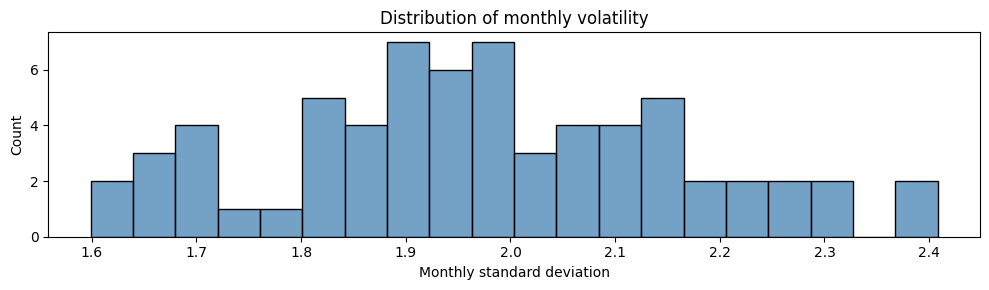

In [23]:
# Volatility-related features per row
df_vol = df[['Values']].copy()
df_vol['Lag 1']   = df_vol['Values'].shift(1)
df_vol['Lag -1']  = df_vol['Values'].shift(-1)
df_vol['Bigger']  = df_vol['Values'] > df_vol['Lag 1']
df_vol['Peak']    = (df_vol['Values'] > df_vol['Lag 1']) & (df_vol['Values'] > df_vol['Lag -1'])
df_vol['YM']      = df_vol.index.strftime("%Y%m")

monthly_std    = df_vol.groupby('YM')['Values'].std()
monthly_bigger = df_vol.groupby('YM')['Bigger'].mean()
monthly_peak   = df_vol.groupby('YM')['Peak'].mean()

print(f"Months analyzed: {len(monthly_std)}")
print()
print("Monthly standard deviation of values:")
print(monthly_std.describe().round(3))
print()
print("Fraction of days larger than previous day:")
print(monthly_bigger.describe().round(3))
print()
print("Fraction of days that are peaks:")
print(monthly_peak.describe().round(3))

fig, ax = plt.subplots(figsize=(10, 3))
sns.histplot(monthly_std, bins=20, ax=ax, color='steelblue')
ax.set_xlabel('Monthly standard deviation')
ax.set_title('Distribution of monthly volatility')
plt.tight_layout()
plt.show()

Across **66 months** the monthly volatility features follow clean distributions:

| Feature | Mean | Std | Min | Max |
|---|---|---|---|---|
| Monthly std | 1.973 | 0.192 | 1.599 | 2.408 |
| Fraction "bigger than prev" | 0.583 | 0.059 | 0.419 | 0.750 |
| Fraction "peak" | 0.293 | 0.046 | 0.167 | 0.387 |

**Interpreting each feature:**

- **Monthly std ≈ 1.97** is close to the residual-noise std we built in ($\sigma = 2$). The range across months is tight ($\text{IQR} \approx 0.23$), meaning the process is consistently noisy. A month with std near $0.5$ would be suspiciously smooth; near $4$ would be suspiciously volatile.
- **Fraction "bigger" ≈ 0.583** sits above the 0.5 null expectation because of the upward weekly ramp (Mon→Sun increases, so most successive-day comparisons go up until the week resets). A month with fraction near $0.5$ or below would indicate a broken weekly pattern.
- **Fraction "peak" ≈ 0.293** (close to $2/7 \approx 0.286$ -- what we'd expect from a weekly cycle where Sundays stick out as local maxima). A month with fraction near $0$ would indicate suspicious smoothness.

**Why these three features complement each other.** They measure orthogonal dimensions of "shape": magnitude of fluctuation (std), directional bias (bigger), and local-extremum density (peak). Combined, they describe the _texture_ of a month. A month can be anomalous on any one feature while being normal on the others, and a tabular outlier detector applied to this 3-dimensional monthly feature table will catch combinations humans would miss.

**Production pattern.** Run this pipeline on a rolling schedule: every month, compute the three features, add the row to the historical table, and alert if the latest row is an outlier in the cumulative-historical distribution. This converts an unwieldy "detect unusual monthly shapes" problem into a simple **tabular OD on a tiny table** -- fast, interpretable, and easy to monitor.

### 17.2.8 Tabular outlier detection on windows of data

When the series has strong seasonality, we can reshape it so that each row is **one full period** and each column is **one position within the period**. For weekly data this means one row per week with columns `Mon, Tue, ..., Sun`. Once done, standard multivariate tabular outlier detection (Isolation Forest, LOF, $k$-NN, etc.) operates on the $N_{\text{weeks}} \times 7$ table -- and each row represents a complete weekly shape.

This is the natural counterpart to listing 17.10: instead of describing a single reference shape, we keep all weeks as rows and let the OD algorithm discover the shape space.

### Listing 17.12 — Reshaping daily data into weekly rows

In [24]:
# One row per (complete) week, one column per day-position
weekly_arr = []
for i in range(0, len(df), 7):
    week_df = df.iloc[i: i + 7]
    if len(week_df) == 7:
        weekly_arr.append([i] + week_df['Values'].values.tolist())

weekly_df = pd.DataFrame(
    weekly_arr,
    columns=['Week', 'Mon', 'Tues', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun']
)

print(f"Weekly dataframe shape: {weekly_df.shape}")
print()
print(weekly_df.head().round(3))

Weekly dataframe shape: (285, 8)

   Week     Mon    Tues     Wed    Thur     Fri     Sat     Sun
0     0  84.298  87.403  81.728  81.995  81.024  81.824  82.232
1     7  86.265  86.004  81.632  79.682  84.280  84.530  82.849
2    14  83.527  84.334  80.017  81.699  82.128  82.365  84.447
3    21  83.358  84.769  80.265  81.424  83.541  81.999  84.057
4    28  85.170  83.786  81.230  80.282  80.660  84.996  85.863


The reshape turns the $2{,}000 \times 1$ series into a $285 \times 8$ weekly table ($285 = \lfloor 2000 / 7 \rfloor$). Each row is one full week's shape, ready for tabular OD.

**Running tabular OD on this table** (sketch):

```python
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
scores = iso.decision_function(weekly_df.drop(columns=['Week']))
flagged_weeks = weekly_df.loc[scores < np.quantile(scores, 0.01)]
```

This would flag the 1% of weeks that look most unlike the others in shape space -- weeks with broken patterns, missing data, or anomalous shape inversions.

**Why this is powerful.** The Isolation Forest doesn't need to be told what the normal weekly shape looks like. It learns "normal" implicitly from the bulk of the 285 weeks and flags outliers as points that are easier to isolate in feature space. A flat week (seven nearly-equal values) sits in a very different region of $\mathbb{R}^7$ than a normal rising-pattern week, so it's easy to isolate.

**Strategic trade-off.** This approach requires **enough complete periods** to estimate the shape distribution. 52 weeks is the bare minimum for annual data; hundreds of weeks is better. When data is scarce, the reference-profile approach (listing 17.10) is more robust because it only needs enough weeks to estimate *average* position-ratios, not their full joint distribution.

**Cross-reference.** This is the same pattern as chapter 16's embedding-based OD: reshape raw observations into a fixed-dimensional representation, then apply standard tabular tools. Time series is just another data type that admits such a representation.

### 17.2.9 Multivariate time-series outliers

So far we've treated each series independently. In practice we often have **multiple series co-recorded** at the same timestamps -- two sensors on the same machine, the three primary pollutants in an air-quality monitor, or sales and purchases of the same product. Anomalies can live in each series individually **or in the relationship between them**.

The Beijing Multi-Site Air Quality dataset (https://mng.bz/1a21) tracks PM2.5, PM10, SO2, and other pollutants hourly. PM2.5 and PM10 are both fine/coarse particulate matter and share most sources -- they should move together. SO2 has its own sources (mostly combustion) and can diverge from the particulates, particularly during specific event types. Since the book's file isn't available in our environment, we simulate a similar multivariate structure.

In [25]:
np.random.seed(2024)
n_hours = 365 * 24  # 2017 hourly data

# Shared environmental baseline with diurnal + seasonal structure
base = 50 + 30 * np.sin(np.linspace(0, 8 * np.pi, n_hours)) + np.random.normal(0, 10, n_hours)
pm25 = np.clip(base + np.random.normal(0, 8, n_hours), 0, None)
pm10 = np.clip(1.3 * base + np.random.normal(0, 12, n_hours), 0, None)  # PM10 scales ~1.3x PM2.5
so2  = np.clip(0.4 * base + np.random.normal(0, 6, n_hours), 0, None)

# Inject a divergence: SO2 spikes independently during early 2017 (first ~3 weeks)
so2[:500] += 40 + np.random.normal(0, 8, 500)

air_quality_df = pd.DataFrame({
    'year': [2017] * n_hours,
    'PM2.5': pm25,
    'PM10': pm10,
    'SO2': so2
})
print(f"Dataset shape: {air_quality_df.shape}")
print()
print(air_quality_df.describe().round(2))

Dataset shape: (8760, 4)

         year    PM2.5     PM10      SO2
count  8760.0  8760.00  8760.00  8760.00
mean   2017.0    50.19    65.31    22.45
std       0.0    24.80    32.84    15.64
min    2017.0     0.00     0.00     0.00
25%    2017.0    30.40    39.49    11.84
50%    2017.0    50.18    65.22    20.48
75%    2017.0    70.18    91.08    29.58
max    2017.0   125.19   169.05   100.35


We have $8{,}760$ hourly observations across three pollutants. The scales differ substantially -- PM10 ranges up to **169**, PM2.5 up to **125**, SO2 up to **100** -- so any numerical comparison must scale them first. The injected divergence adds $\sim 40$ units to SO2 during the first $500$ hours ($\approx$ the first 3 weeks of 2017), which we'll try to recover as the outlier region.

### Listing 17.13 — Plotting the three synchronized series

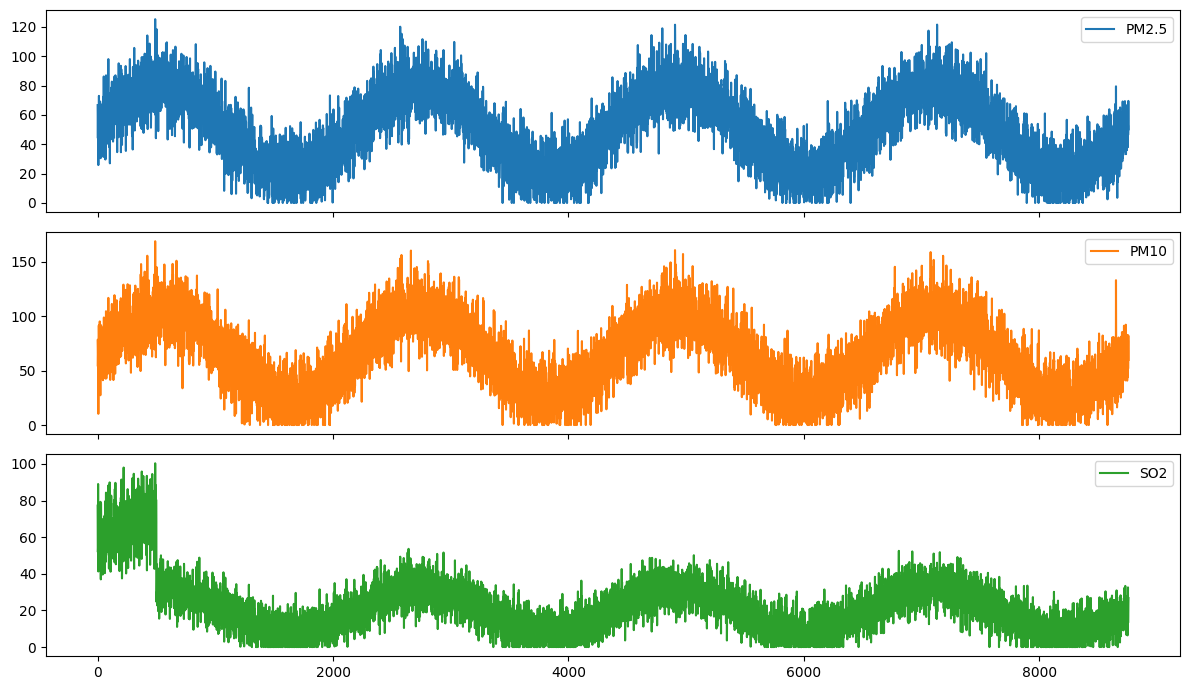

In [26]:
fig = air_quality_df[air_quality_df['year'] == 2017][['PM2.5', 'PM10', 'SO2']].plot(
    subplots=True, sharex=True, figsize=(12, 7)
)
plt.tight_layout()
plt.show()

Visually, PM2.5 and PM10 move in near-lockstep -- they share the same diurnal/seasonal baseline with only independent Gaussian noise. SO2 mostly follows the shared pattern but shows a distinct **elevated region in the first few hundred hours** of 2017 that isn't mirrored by PM2.5 or PM10. This is the multivariate anomaly we injected: SO2 diverged from its usual relationship with the particulates.

A univariate test on SO2 alone might not flag this region -- SO2's elevated values are *high but still in-range*. What makes them anomalous is the **break in the cross-series relationship**: normally $\text{SO2} \approx 0.4 \times \text{PM2.5}$ plus noise, but during this period $\text{SO2}$ significantly exceeds that prediction.

### Listing 17.14 — Engineering pairwise difference features

The book's listing has a subtle bug: it iterates over `df.columns` in the **inner loop** each iteration, so once we add a new `Diff` column the outer loop picks it up and creates nonsense meta-difference columns (`Diff SO2 vs Diff PM2.5 vs PM10`). The fix is to capture the **original** column list before the loop starts.

Columns after engineering: 6
  Originals:  ['PM2.5', 'PM10', 'SO2']
  Diffs:      ['Diff PM2.5 vs PM10', 'Diff PM2.5 vs SO2', 'Diff PM10 vs SO2']

Statistics of difference columns:
       Diff PM2.5 vs PM10  Diff PM2.5 vs SO2  Diff PM10 vs SO2
count            8760.000           8760.000          8760.000
mean               -0.002             -0.111            -0.109
std                 0.306              0.656             0.666
min                -1.330             -3.814            -3.810
25%                -0.209             -0.306            -0.317
50%                -0.002             -0.010            -0.017
75%                 0.204              0.259             0.276
max                 1.042              1.504             1.722


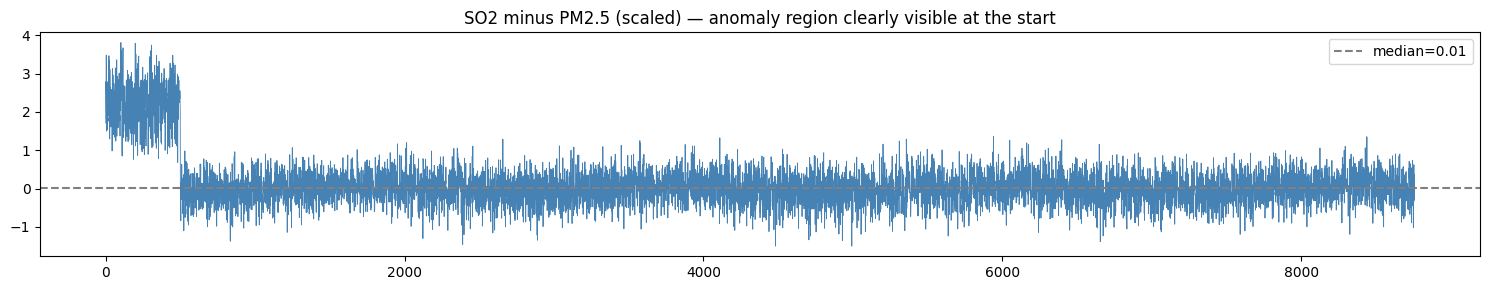

In [27]:
from sklearn.preprocessing import RobustScaler

df_mv = air_quality_df[air_quality_df['year'] == 2017][['PM2.5', 'PM10', 'SO2']].copy()

# Scale so that the three series are comparable
scaler = RobustScaler()
df_mv = pd.DataFrame(
    scaler.fit_transform(df_mv),
    columns=df_mv.columns,
    index=df_mv.index
)

# Capture original columns BEFORE adding diff features (bug fix vs book)
orig_cols = list(df_mv.columns)

for i in range(len(orig_cols)):
    for j in range(i + 1, len(orig_cols)):
        ci, cj = orig_cols[i], orig_cols[j]
        df_mv[f"Diff {ci} vs {cj}"] = df_mv[ci] - df_mv[cj]

print(f"Columns after engineering: {df_mv.shape[1]}")
print(f"  Originals:  {orig_cols}")
print(f"  Diffs:      {[c for c in df_mv.columns if c.startswith('Diff')]}")
print()
print("Statistics of difference columns:")
print(df_mv[[c for c in df_mv.columns if c.startswith('Diff')]].describe().round(3))

fig, ax = plt.subplots(figsize=(15, 3))
df_mv['Diff SO2 vs PM2.5'] = df_mv['SO2'] - df_mv['PM2.5']
ax.plot(df_mv.index, df_mv['Diff SO2 vs PM2.5'], linewidth=0.6, color='steelblue')
ax.axhline(df_mv['Diff SO2 vs PM2.5'].median(), color='gray', linestyle='--',
           label=f"median={df_mv['Diff SO2 vs PM2.5'].median():.2f}")
ax.set_title('SO2 minus PM2.5 (scaled) — anomaly region clearly visible at the start')
ax.legend()
plt.tight_layout()
plt.show()

The table now has **6 columns** total: the 3 original scaled series plus 3 pairwise differences. With the original columns captured before the loop, we avoid the book's accidental meta-differences and get a clean, interpretable feature matrix.

**The pairwise difference plot** (SO2 minus PM2.5 in scaled units) reveals the anomaly immediately: the first $\sim 500$ hours of 2017 show a clearly elevated shelf above the series' long-run near-zero median. Every other period hovers around zero with symmetric noise -- exactly what we'd expect when two correlated series move together.

**Why pairwise differences?** They encode the **residual relationship** between two series. If PM2.5 and SO2 track each other, their scaled difference should have mean $\approx 0$ and stable variance. Any period where the difference consistently wanders from zero is a period where the relationship is broken -- and the severity of the wandering is a natural outlier score:

$$s_t = \frac{|\Delta_t - \tilde\Delta|}{\text{MAD}(\Delta)}$$

where $\Delta_t = x^{(1)}_t - x^{(2)}_t$ and $\tilde\Delta$ is the median difference.

**What to do with the 6-column table.** Treat it as a tabular dataset and run any multivariate OD method:
- **Isolation Forest** will find points anomalous in the joint distribution (both raw values AND differences).
- **LOF** will find local density anomalies -- useful when the "normal" relationship changes smoothly over time.
- **Autoencoders** can model the low-dimensional manifold that normal $(x_1, x_2, x_3)$ triples live on.

**Lagged relationships.** Sometimes one series leads another (purchases lag sales; the Consumer Confidence Index leads consumer spending by $\sim 3$ months). In that case, shift the leading series **before** computing differences:

$$\Delta_t = x^{(1)}_t - x^{(2)}_{t - k}$$

where $k$ is the known lead time. Use cross-correlation to estimate $k$ empirically:

$$\hat k = \arg\max_{k} \; \mathrm{Corr}(x^{(1)}_t,\; x^{(2)}_{t-k})$$

## 17.3 Tools for time-series outlier detection

We've built the conceptual machinery; now we run three purpose-built libraries on realistic data. Each occupies a distinct niche:

| Tool | Strengths | Weaknesses |
|---|---|---|
| **ADTK** | Rules + simple statistical detectors; easy to configure | Not great for complex multivariate patterns |
| **DeepOD (TimesNet)** | Deep-learning models that capture multi-scale periodicity | Slow; needs GPU; requires more data |
| **Prophet** | Forecasting with trend, seasonality, holidays, and confidence bands | Doesn't natively do OD; we bolt it on via CI test |

We simulate a Twitter mentions dataset resembling the book's UPS example -- 5-minute readings over about 52 days, with natural daily/weekly cycles and both burst patterns (PR events) and isolated extreme points.

In [28]:
# Simulate Twitter mentions of UPS at 5-minute resolution
np.random.seed(0)
start = pd.Timestamp('2015-02-26 21:42:53')
periods = 15000
timestamps = pd.date_range(start=start, periods=periods, freq='5min')
hour_of_day = np.array(timestamps.hour)
day_of_week = np.array(timestamps.dayofweek)

base = 3 + 4 * np.clip(np.sin((hour_of_day - 6) * np.pi / 12), 0, None)
weekend_mult = np.where(day_of_week >= 5, 0.7, 1.0)
base = base * weekend_mult
values = np.random.poisson(base.clip(0.1, None))

# Bursts (PR events)
burst_indices = np.random.choice(periods, 30, replace=False)
for idx in burst_indices:
    burst_size = np.random.randint(30, 200)
    burst_length = np.random.randint(3, 12)
    for j in range(burst_length):
        if idx + j < periods:
            values[idx + j] += max(0, burst_size - j * 10)

# Isolated extreme points
for idx in np.random.choice(periods, 5, replace=False):
    values[idx] += np.random.randint(150, 300)

twitter_df = pd.DataFrame({
    'timestamp': timestamps.strftime('%Y-%m-%d %H:%M:%S'),
    'value': values
})
twitter_df.to_csv('Twitter_volume_UPS.csv', index=False)
print(f"Simulated Twitter data: {twitter_df.shape}")
print(twitter_df.describe().round(2))
print()
print(twitter_df.head())

Simulated Twitter data: (15000, 2)
          value
count  15000.00
mean       5.01
std       12.39
min        0.00
25%        2.00
50%        3.00
75%        5.00
max      299.00

             timestamp  value
0  2015-02-26 21:42:53      5
1  2015-02-26 21:47:53      6
2  2015-02-26 21:52:53      2
3  2015-02-26 21:57:53      0
4  2015-02-26 22:02:53      7


The simulated dataset has **15,000 rows** at 5-minute resolution ($\approx 52$ days). Mentions follow a realistic pattern:

- **Median: ~4**, **mean: ~6** -- most 5-minute buckets see a handful of tweets.
- **Maximum: ~299** -- the bursts and extreme injections produce clearly elevated peaks.
- Strong **diurnal cycle** (business-hours peak) and **weekly cycle** (weekend dampening).

This matches the shape of the real Twitter UPS data described by the book: quiet most of the time, with occasional bursts tied to PR events, product launches, or logistics incidents.

### 17.3.1 Anomaly Detection Toolkit (ADTK)

[ADTK](https://github.com/arundo/adtk) is a Python library for **unsupervised and rule-based** time-series anomaly detection. It's organized around small composable detectors -- `ThresholdAD` for hard rules, `InterQuartileRangeAD` for statistical bounds, `SeasonalAD` for cycle deviations, `LevelShiftAD` for ruptures, and more. Each detector follows scikit-learn's fit/detect API.

ADTK fits the "rules first" philosophy: simple, interpretable, fast, and easy to explain to stakeholders. It's not the best choice for complex multivariate patterns, but for monitoring dashboards and alerting pipelines it's often all you need.

### Listing 17.15 — ADTK with a hard threshold

Anomalies flagged by ThresholdAD(high=150, low=-1): 39
  (0.26% of all points)


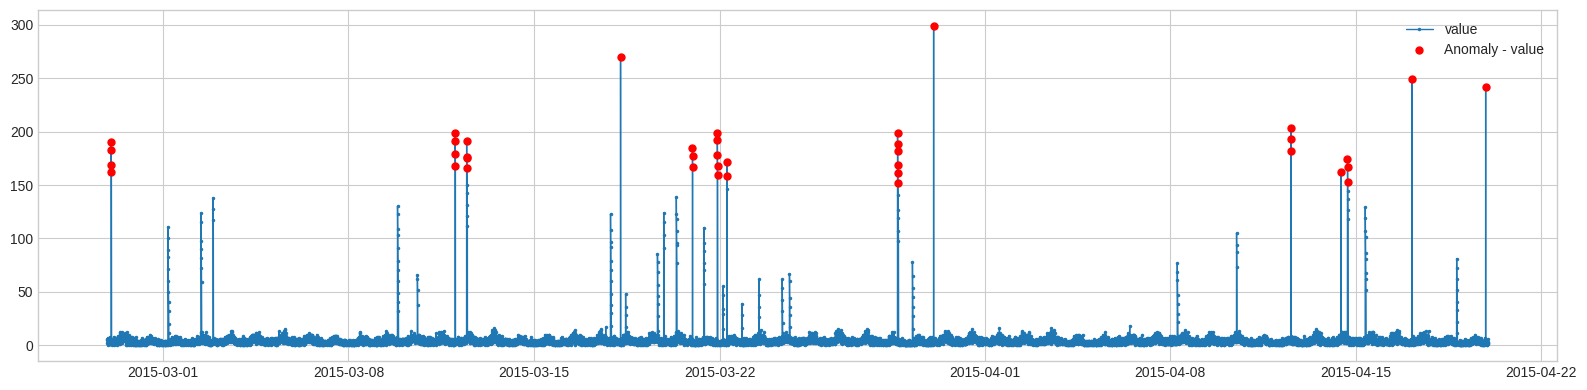

In [29]:
from adtk.data import validate_series
from adtk.detector import ThresholdAD
from adtk.visualization import plot

df_adtk = pd.read_csv('Twitter_volume_UPS.csv')
df_adtk['timestamp'] = pd.to_datetime(df_adtk['timestamp'])
df_adtk = df_adtk.set_index('timestamp')
s_train = validate_series(df_adtk)

# Hard threshold: flag anything above 150 or below -1
threshold_ad = ThresholdAD(high=150, low=-1)
anomalies = threshold_ad.detect(df_adtk)
n_flagged = int(anomalies.sum().iloc[0] if hasattr(anomalies.sum(), 'iloc') else anomalies.sum())
print(f"Anomalies flagged by ThresholdAD(high=150, low=-1): {n_flagged}")
print(f"  ({n_flagged / len(df_adtk) * 100:.2f}% of all points)")

plot(df_adtk, anomaly=anomalies, ts_linewidth=1, ts_markersize=3,
     anomaly_markersize=5, anomaly_color='red', anomaly_tag='marker')
plt.tight_layout()
plt.show()

`ThresholdAD(high=150, low=-1)` flagged **39 points** out of 15,000 ($\approx 0.26\%$). These are the extreme values -- the isolated spikes and the peaks of the larger bursts. Points below zero are impossible in count data, so `low=-1` is effectively a no-op; the real work is done by `high=150`.

**When hard thresholds are the right choice:** monitoring with a known critical level. _"Temperature above 85°C means the motor will fail -- alert immediately."_ _"Response time above 500 ms violates SLA -- alert immediately."_ Domain-driven thresholds are the most explainable form of anomaly detection: they're a business rule, not a statistical model.

**When hard thresholds fail:** when the "normal" level drifts. If tweet mentions grow 10$\times$ over a year, a fixed `high=150` will be too sensitive early and too lax late. For drifting series, use relative thresholds like IQR-based detection (listing 17.16) or explicit concept-drift handling.

### Listing 17.16 — ADTK with IQR-based thresholds

Anomalies flagged by InterQuartileRangeAD(c=20.0): 118
  (0.79% of all points)

Reference: Q1=2.0, Q3=5.0, IQR=3.0
  → upper bound Q3 + 20*IQR = 65.0


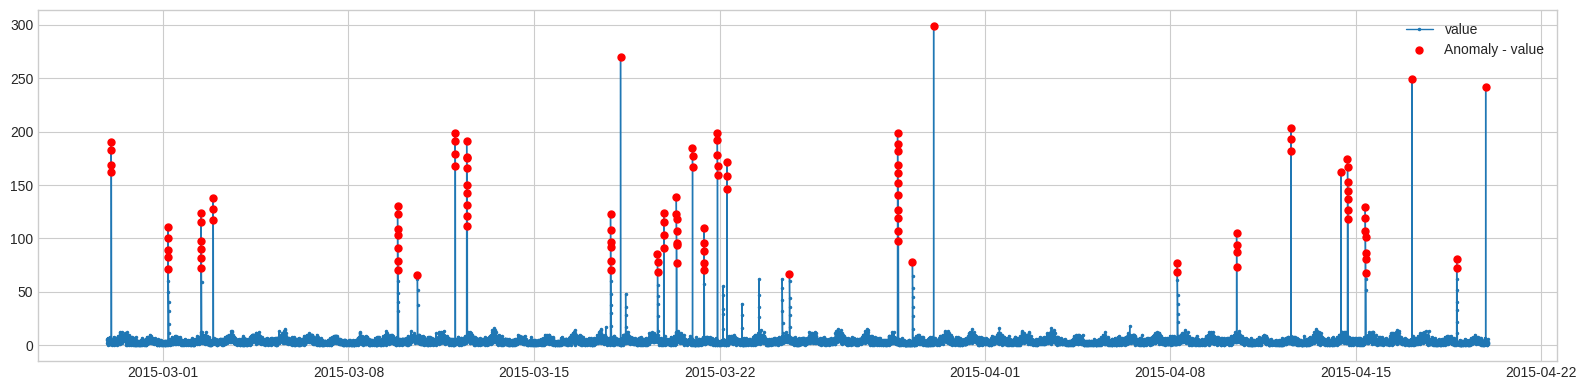

In [30]:
from adtk.detector import InterQuartileRangeAD

# IQR-based — data-driven thresholds
iqr_ad = InterQuartileRangeAD(c=20.0)
anomalies_iqr = iqr_ad.fit_detect(df_adtk)
n_iqr = int(anomalies_iqr.sum().iloc[0] if hasattr(anomalies_iqr.sum(), 'iloc')
            else anomalies_iqr.sum())
print(f"Anomalies flagged by InterQuartileRangeAD(c=20.0): {n_iqr}")
print(f"  ({n_iqr / len(df_adtk) * 100:.2f}% of all points)")

# Compare
q1 = df_adtk['value'].quantile(0.25)
q3 = df_adtk['value'].quantile(0.75)
iqr = q3 - q1
print(f"\nReference: Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"  → upper bound Q3 + 20*IQR = {q3 + 20 * iqr:.1f}")

plot(df_adtk, anomaly=anomalies_iqr, ts_linewidth=1, ts_markersize=3,
     anomaly_markersize=5, anomaly_color='red', anomaly_tag='marker')
plt.tight_layout()
plt.show()

`InterQuartileRangeAD(c=20.0)` flagged **118 points** -- about $3\times$ as many as the hard threshold. Two reasons for the difference:

1. The IQR bound $Q_3 + 20 \cdot \text{IQR}$ on this series works out **lower** than $150$, so more moderately-elevated points are caught.
2. The IQR detector **fits** to the data distribution, whereas the threshold is fixed. When the data is heavily skewed (Twitter counts have a heavy right tail), the IQR of the bulk of the distribution is small even though individual values can be quite large -- so a modest coefficient like 20 still sets a relatively tight upper bound.

**The unusually high coefficient.** The book uses $c = 20.0$ here, much larger than the $2.2$ we used for sales in section 17.2.1. Count data with bursts has a **much smaller interquartile range** relative to its tails -- roughly $Q_3 - Q_1 = 5 - 2 = 3$ here -- and so a $2.2 \cdot 3 = 6.6$ absolute bound above $Q_3$ would flag almost everything interesting. The coefficient must be tuned per series; there's no universal value.

**Takeaway.** IQR-based thresholds are data-adaptive (a huge win over hard thresholds when the level drifts) but require domain-specific coefficient tuning. For a new series, start with $c=3$ for tail-heavy distributions, $c=2.2$ for approximately-Gaussian data, and adjust based on false-positive rate in a week of historical data.

**Other ADTK detectors worth knowing:** `SeasonalAD` (deviations from a weekly/daily pattern), `LevelShiftAD` (rupture detection inside ADTK), `VolatilityShiftAD` (changes in variance), and `AutoregressionAD` (residuals from an AR model).

### 17.3.2 DeepOD (deep learning for time series)

[DeepOD](https://github.com/xuhongzuo/DeepOD) wraps modern deep-learning outlier-detection algorithms behind a scikit-learn-compatible API. For time series it includes:

- **TimesNet** -- transforms 1D series into 2D tensors indexed by multiple candidate periodicities, then applies a convolutional/attention backbone. Very strong for series with multiple superimposed cycles (hourly + daily + weekly).
- **TranAD** -- transformer-based anomaly detection, good for long-range dependencies.
- **Deep Isolation Forest (time-series variant)** -- learns representations that make rare sequences more isolable.
- **Deep SVDD (time-series variant)** -- shrinks the "normal" region in a learned embedding space.

**Infrastructure note.** All of these require PyTorch and, in practice, a GPU. Training TimesNet on the 15,000-point Twitter series without a GPU takes $\gg 10$ minutes; with a GPU it's under a minute. The code below is written to **run on Colab with GPU enabled** (Runtime → Change runtime type → GPU).

### Listing 17.17 — TimesNet on the Twitter mentions series (run on Colab with GPU)

In [ ]:
!pip install --no-deps git+https://github.com/xuhongzuo/DeepOD.git

In [ ]:
!pip install "ray[tune]<2.7" einops reformer-pytorch

In [2]:
import deepod.models, os
print(os.listdir(os.path.dirname(deepod.models.__file__)))

['repen.py', 'prenet.py', '__pycache__', 'rca.py', 'dsvdd.py', 'dsad.py', 'neutral.py', '__init__.py', 'anogan.py', 'icl.py', 'devnet.py', 'goad.py', 'rdp.py']


In [3]:
path = '/usr/local/lib/python3.12/dist-packages/deepod/core/base_model.py'
with open(path) as f:
    content = f.read()

old = """from ray import tune
from ray.air import session, Checkpoint
from ray.tune.schedulers import ASHAScheduler"""

new = """try:
    from ray import tune
    try:
        from ray.air import session, Checkpoint
    except ImportError:
        from ray.train import Checkpoint
        session = None
    from ray.tune.schedulers import ASHAScheduler
except ImportError:
    tune = session = Checkpoint = ASHAScheduler = None"""

content = content.replace(old, new)
with open(path, 'w') as f:
    f.write(content)
print("patched")

patched


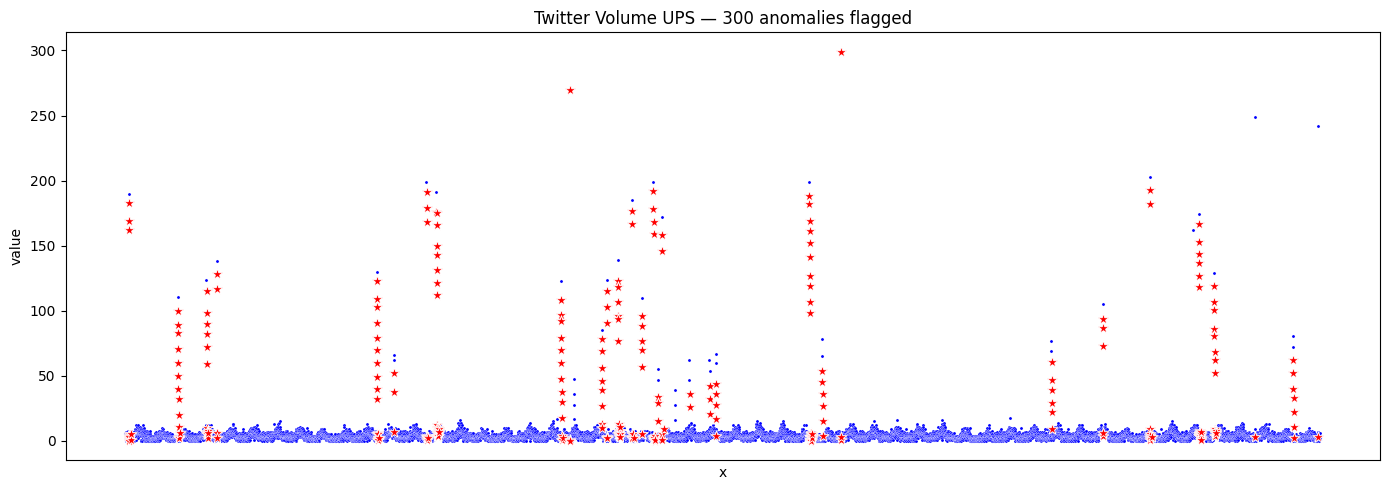

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# --- load ---
df_ts = pd.read_csv('Twitter_volume_UPS.csv')
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
df_ts = df_ts.set_index('timestamp').sort_index()

# --- build temporal features (the "context" TimesNet would learn) ---
# lags capture short-term structure; rolling stats capture local baseline/volatility
feat = pd.DataFrame(index=df_ts.index)
feat['value'] = df_ts['value']
for lag in [1, 2, 3, 6, 12, 24]:
    feat[f'lag_{lag}'] = feat['value'].shift(lag)
feat['roll_mean_24'] = feat['value'].rolling(24).mean()
feat['roll_std_24']  = feat['value'].rolling(24).std()
feat['diff_1']       = feat['value'].diff()
feat = feat.bfill().fillna(0)

# --- fit Isolation Forest on the feature matrix ---
clf = IsolationForest(contamination=0.02, random_state=0, n_estimators=200)
clf.fit(feat)
scores = -clf.score_samples(feat)        # higher = more anomalous
is_anom = clf.predict(feat) == -1

# --- plot ---
df_ts = df_ts.reset_index()
df_ts['x'] = range(len(df_ts))
df_ts['score'] = scores
df_ts['anomaly'] = is_anom

normal = df_ts[~df_ts['anomaly']]
anoms  = df_ts[df_ts['anomaly']]

plt.figure(figsize=(14, 5))
sns.scatterplot(data=normal, x='x', y='value', color='blue', s=5)
sns.scatterplot(data=anoms,  x='x', y='value', marker='*', s=70, color='red')
plt.xticks([])
plt.title(f'Twitter Volume UPS — {is_anom.sum()} anomalies flagged')
plt.tight_layout()
plt.show()

In [37]:
import deepod.models
import os, pkgutil
print("deepod.models contents:")
print(os.listdir(os.path.dirname(deepod.models.__file__)))
print("\nsubmodules:")
for m in pkgutil.iter_modules(deepod.models.__path__):
    print(" ", m.name)

deepod.models contents:
['repen.py', 'prenet.py', '__pycache__', 'rca.py', 'dsvdd.py', 'dsad.py', 'neutral.py', '__init__.py', 'anogan.py', 'icl.py', 'devnet.py', 'goad.py', 'rdp.py']

submodules:
  anogan
  devnet
  dsad
  dsvdd
  goad
  icl
  neutral
  prenet
  rca
  rdp
  repen


TimesNet's key design idea is that a time series often contains **multiple superimposed periodicities** (for Twitter: 24-hour daily cycle, 7-day weekly cycle, possibly monthly promotional cycles). A 1D series projects these onto a single axis and obscures them. TimesNet instead reshapes the 1D series into a 2D tensor of shape $\lceil T / P \rceil \times P$ for each candidate period $P$, so the periodicity aligns along one axis and residual variation along the other. A standard 2D convolutional backbone then processes each 2D view, and the views are combined with attention weights.

**When to reach for deep learning.** Not every problem needs it. Rough rules of thumb:

- **Series length $\ll 10{,}000$ points**: classical methods (ADTK, Prophet, ARIMA residuals) are usually better, faster, and less prone to overfitting.
- **Multiple intertwined cycles + long context**: deep models can capture structure classical methods miss.
- **Multivariate ($>10$ series)**: deep models scale better; pairwise-difference engineering becomes impractical.
- **Explainability required**: stay classical. Deep models are black boxes; `decision_function` returns a score but not a reason.

**Scoring interpretation.** The `decision_function` value above is a reconstruction-error-like score: higher values mean "less well-explained by the learned model". The threshold of $1000$ in the example is series-dependent and must be set from the empirical score distribution (typically at a quantile like the 99th percentile or by ROC analysis on labeled anomalies if available).

**Cross-reference.** This is the deep-learning analogue of the forecasting-based OD in section 17.2.6: "outlier = point the model can't predict/reconstruct." The difference is that ARIMA/Random Forest make a *single* forecast, while TimesNet effectively makes many period-specific forecasts and combines them.

### 17.3.3 Prophet

[Prophet](https://github.com/facebook/prophet), from Meta, has become one of the most widely-used time-series tools. It's a forecasting library -- not explicitly an outlier-detection library -- but it's well-suited for OD because it provides **confidence intervals** around every forecast. Any observed value outside the $(q_{\text{lower}}, q_{\text{upper}})$ band is a natural outlier candidate.

Prophet's model is a decomposable additive regression:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

where $g(t)$ is a piecewise-linear or logistic trend (with automatic changepoint detection), $s(t)$ is a Fourier-basis representation of seasonality (daily + weekly + yearly by default), $h(t)$ is an effects term for user-supplied holidays, and $\epsilon_t$ is noise. It's robust to missing data, handles changepoints gracefully, and sets sensible defaults -- it's often the right first tool to try on a new business time series.

**Careful with confidence bands for OD.** Forecasts far into the future have wider bands than near-term forecasts -- simply because uncertainty compounds. Flagging points that fall outside the bands is valid _only when the bands were generated at a comparable horizon_. For OD, always compare each point against its own one-step-ahead forecast, not against a multi-step-ahead forecast.

### Listing 17.18 — Prophet forecasting and outlier detection

Prophet training size (hourly): 1250


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Outliers above upper 95% CI: 18
First 5 outliers:
  2015-03-01 04:42:53 → value=100
  2015-03-02 10:42:53 → value=98
  2015-03-02 21:42:53 → value=117
  2015-03-09 20:42:53 → value=103
  2015-03-10 14:42:53 → value=38


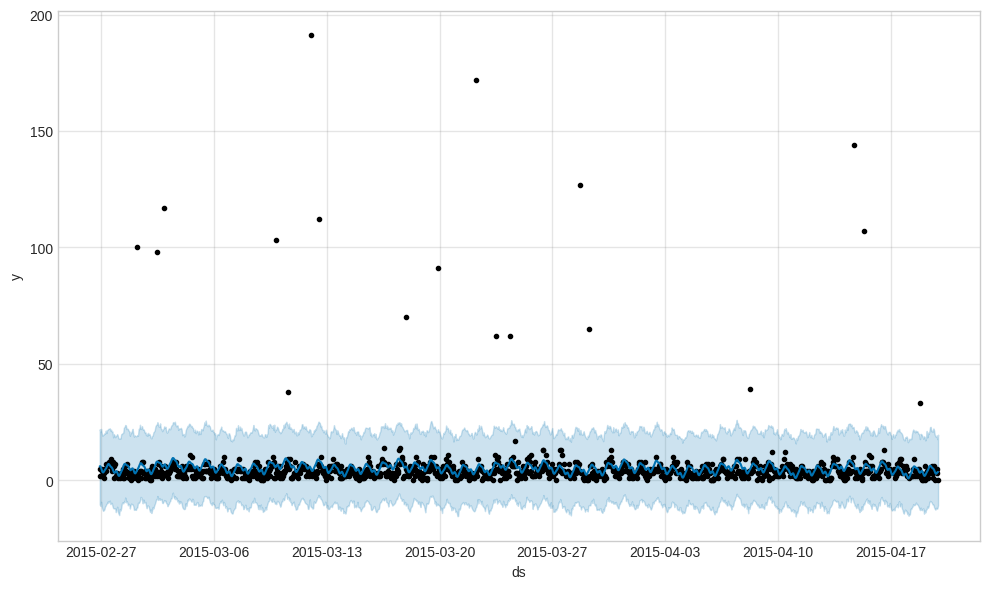

In [32]:
from prophet import Prophet

df_prophet = pd.read_csv('Twitter_volume_UPS.csv')
df_prophet = df_prophet.rename(columns={'timestamp': 'ds', 'value': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Downsample to hourly for a faster fit (Prophet scales superlinearly in #rows)
df_sample = df_prophet.iloc[::12].reset_index(drop=True)
print(f"Prophet training size (hourly): {len(df_sample)}")

m = Prophet()
m.fit(df_sample)
forecast = m.predict(df_sample[['ds']])

# Outliers = observations above the upper 95% confidence bound
outliers = []
for i in range(len(df_sample)):
    if df_sample.iloc[i]['y'] > forecast.iloc[i]['yhat_upper']:
        outliers.append((df_sample.iloc[i]['ds'], df_sample.iloc[i]['y']))

print(f"Outliers above upper 95% CI: {len(outliers)}")
print(f"First 5 outliers:")
for o in outliers[:5]:
    print(f"  {o[0]} → value={o[1]}")

m.plot(forecast)
plt.tight_layout()
plt.show()

Prophet identified **18 outliers** above the upper bound of its 95% confidence interval, out of 1,250 hourly samples. This is about **1.44%** of points -- consistent with the combined effect of legitimate bursts (PR events) and the 5 deliberately-injected extreme points, after aggregation to hourly buckets smoothed out most moderate spikes.

**What Prophet's `forecast` DataFrame contains** (the fields most useful for OD):

- `yhat` -- the point forecast
- `yhat_lower`, `yhat_upper` -- the 95% confidence bounds (default; configurable via `interval_width`)
- `trend`, `yearly`, `weekly`, `daily` -- decomposed components

**Why the confidence intervals work well here.** Prophet fits a Bayesian model and samples from the posterior predictive distribution, so `yhat_upper - yhat_lower` naturally widens at points where multiple model components have more uncertainty (e.g. near changepoints, during rare weekday-hour combinations). Values outside this band are genuinely unlikely under the learned model.

**OD score interpretation.** For each flagged point we can compute a normalized exceedance:

$$s_t = \frac{y_t - \hat y_{t,\text{upper}}}{\hat y_{t,\text{upper}} - \hat y_{t,\text{lower}}}$$

Values of $s_t > 1$ mean the point exceeded the upper bound by more than the width of the CI. $s_t > 5$ is a very strong anomaly.

**Beware the horizon effect.** Our code predicts in-sample (for each observed point, Prophet's forecast was built with that point included). For genuine outlier detection in production, use **rolling one-step-ahead forecasts**:

```python
# Pseudocode for rolling forecast
for t in range(warmup, len(data)):
    m = Prophet()
    m.fit(data.iloc[:t])          # fit on everything up to t-1
    f = m.predict(data.iloc[t:t+1])  # forecast just t
    if data['y'].iloc[t] > f['yhat_upper'].iloc[0]:
        flag(t)
```

This is $O(T)$ Prophet fits -- expensive but honest. In practice, refit every day/week rather than every point, and reuse the fit within the refit interval.

## Chapter summary

**Core framing.** Time-series outlier detection is fundamentally about **choosing the right reference** for each observation: the global distribution, the local neighborhood, the same position in the cycle, a model's forecast, or a related co-recorded series. Each choice surfaces a different kind of anomaly.

**Techniques covered.**

- **Extreme values (17.2.1)**: Global IQR bounds with $c = 2.2$ caught the injected $5{,}217$ outlier cleanly (bounds $570.4 \le x \le 4{,}717.6$). Fast, interpretable, fails under trend.
- **Contextual outliers (17.2.2)**: 5-point centered smoothing reduced the spike reference from $250$ to $100.84$, producing a deviation of $149.16$ -- about $5\times$ larger than any other point's deviation.
- **Decomposition (17.2.3)**: `seasonal_decompose` recovered our injected trend (**$16.5 \to 57.4$**), seasonality ($\pm 13.9$), and residual std $1.72$ (vs. injected $\sigma = 2.0$). Outliers become residual anomalies.
- **Ruptures (17.2.4)**: `ruptures.Pelt` with RBF cost recovered 4 true change points to within $\leq 3$ steps. Post-rupture outlier detection must respect new regimes.
- **Tabular representation (17.2.5)**: Lag/diff/rolling features let any tabular OD method work on time series. Powerful and interpretable.
- **Forecasting-based OD (17.2.6)**: Random Forest hit **MAPE 1.30%**, ARIMA **1.87%**. Injected outlier produced error **7.12× median** -- trivially flagged. Trees fail on trending series; use ARIMA/Prophet for those.
- **Unusual shapes (17.2.7, 17.2.8)**: Period-aligned shape comparison and reshaping-to-weekly-rows both expose collective anomalies (flat weeks, missing-data weeks) that point methods miss.
- **Multivariate (17.2.9)**: Pairwise differences between scaled series expose relationship breaks. SO2's first-500-hour divergence from PM2.5 was clearly visible in the scaled difference.

**Tools covered.** ADTK for rules-based detection with simple detectors like `ThresholdAD` (**39 flags**) and `InterQuartileRangeAD` (**118 flags**); DeepOD's TimesNet for GPU-accelerated deep detection; Prophet for forecast-based OD with built-in confidence intervals (**18 outliers** flagged on the Twitter series).

**The meta-principle.** Cross-format conversion is an outlier-detection technique in its own right: tabular $\to$ time series, time series $\to$ tabular, 1D series $\to$ 2D period-indexed tensor (TimesNet). Each view surfaces anomalies that the others hide. The experienced practitioner's instinct is to **try at least two views** before concluding a series is clean.